In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings, os, time as _time, json as json_mod

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
warnings.filterwarnings('ignore')

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
OUT_DIR = Path('output/S3_polyfit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
cases['snr_float'] = cases['snr'].apply(lambda x: float(x))

pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']
case_idx_map = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

df = cases.merge(
    metrics[['case_id', 'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho']],
    on='case_id', how='inner',
)

null_data = df[df['family_id'] == 'Null'].copy()

variants = {}
for vname in ['strong', 'mild']:
    v = df[df['variant_level'] == vname].copy()
    v = pd.concat([v, null_data], ignore_index=True)
    v = v[np.isfinite(v['snr_float'])].copy()
    v['abs_rho'] = v['spearman_rho'].abs()
    v['abs_r']   = v['pearson_r'].abs()
    variants[vname] = v

print(f'Strong: {len(variants["strong"]):,} rows')
print(f'Mild:   {len(variants["mild"]):,} rows')
ALPHA = 0.5

Strong: 55,350 rows
Mild:   55,350 rows


In [2]:
# ══════════════════════════════════════════════════════
#  Human annotations — both variants
# ══════════════════════════════════════════════════════

ANNOT = {
    'strong': {
        'NO_GLOBAL': ['F07', 'F08', 'F19', 'F20'],
        'CLEAR_SNR_S1': {
            'F01': 3.0, 'F02': 3.0,
            'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
            'F09': 2.0, 'F10': 2.0, 'F11': 2.0, 'F12': 2.0,
            'F13': 5.0, 'F14': 5.0, 'F15': 5.0, 'F16': 5.0,
            'F17': 1.0, 'F18': 1.0, 'F19': 1.0, 'F20': 1.0,
            'F21': 3.0, 'F22': 3.0, 'F23': 8.0, 'F24': 8.0,
            'F25': 8.0, 'F26': 8.0,
        },
        'THRESHOLD_SNR_S1': {
            'F01': 0.3, 'F02': 0.3,
            'F03': 0.3, 'F04': 0.3, 'F05': 0.3, 'F06': 0.3,
            'F09': 0.3, 'F10': 0.3, 'F11': 0.3, 'F12': 0.3,
            'F13': 1.0, 'F14': 1.0, 'F15': 0.5, 'F16': 0.5,
            'F17': 0.3, 'F18': 0.3, 'F19': 0.1, 'F20': 0.1,
            'F21': 0.3, 'F22': 0.3, 'F23': 3.0, 'F24': 3.0,
            'F25': 1.0, 'F26': 1.0,
        },
        'SIMPLE_FAM': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_S2': ['F13','F14','F15','F16'],
        'COMPLEX_FAM': ['F17','F18','F21','F22','F23','F24','F25','F26'],
        'CLEAR_SNR_S2': {
            'F01': 2.0, 'F02': 2.0, 'F03': 2.0, 'F04': 2.0,
            'F05': 3.0, 'F06': 3.0,
            'F09': 3.0, 'F10': 3.0, 'F11': 3.0, 'F12': 3.0,
            'F13': 15.0, 'F14': 15.0,
        },
        'THRESHOLD_SNR_S2': {
            'F01': 0.3, 'F02': 0.3, 'F03': 0.3, 'F04': 0.3,
            'F05': 0.5, 'F06': 0.5,
            'F09': 0.5, 'F10': 0.5, 'F11': 0.5, 'F12': 0.5,
            'F13': 1.0, 'F14': 1.0,
        },
        'STRONG_MONO': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_MONO': [],
        'WEAK_MONO': ['F13','F14','F15','F16'],
        'CLEAR_SNR_S3': {
            'F01': 10.0, 'F02': 10.0, 'F03': 10.0, 'F04': 10.0,
            'F05': 10.0, 'F06': 10.0,
            'F09': 10.0, 'F10': 10.0, 'F11': 10.0, 'F12': 10.0,
        },
        'THRESHOLD_SNR_S3': {
            'F01': 0.0, 'F02': 0.0, 'F03': 0.0, 'F04': 0.0,
            'F05': 0.0, 'F06': 0.0,
            'F09': 0.0, 'F10': 0.0, 'F11': 0.0, 'F12': 0.0,
        },
        'LINEAR_FAM': ['F01', 'F02'],
        'UNCERTAIN_LINEAR': [],
        'NONLINEAR_FAM': ['F03','F04','F05','F06','F09','F10','F11','F12'],
        'CLEAR_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'THRESHOLD_SNR_S4': {'F01': 0.0, 'F02': 0.0},
        'CURVATURE_FAMILY_CLASS': {
            'F03': 'Convex',   'F04': 'Concave',
            'F05': 'Concave',  'F06': 'Convex',
            'F09': 'Concave',  'F10': 'Convex',
            'F11': 'Convex',   'F12': 'Concave',
        },
    },
    'mild': {
        'NO_GLOBAL': ['F19', 'F20'],
        'CLEAR_SNR_S1': {
            'F01': 5.0, 'F02': 5.0,
            'F03': 5.0, 'F04': 5.0, 'F05': 5.0, 'F06': 5.0,
            'F07': 5.0, 'F08': 5.0,
            'F09': 5.0, 'F10': 5.0, 'F11': 5.0, 'F12': 5.0,
            'F13': 8.0, 'F14': 8.0, 'F15': 8.0, 'F16': 8.0,
            'F17': 1.0, 'F18': 1.0, 'F19': 1.0, 'F20': 1.0,
            'F21': 3.0, 'F22': 3.0, 'F23': 10.0, 'F24': 8.0,
            'F25': 8.0, 'F26': 8.0,
        },
        'THRESHOLD_SNR_S1': {
            'F01': 2.0, 'F02': 2.0,
            'F03': 2.0, 'F04': 2.0, 'F05': 2.0, 'F06': 2.0,
            'F07': 2.0, 'F08': 2.0,
            'F09': 2.0, 'F10': 2.0, 'F11': 2.0, 'F12': 2.0,
            'F13': 5.0, 'F14': 5.0, 'F15': 5.0, 'F16': 5.0,
            'F17': 0.3, 'F18': 0.3, 'F19': 0.1, 'F20': 0.1,
            'F21': 0.3, 'F22': 0.3, 'F23': 3.0, 'F24': 3.0,
            'F25': 1.0, 'F26': 1.0,
        },
        'SIMPLE_FAM': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_S2': ['F13','F14','F15','F16'],
        'COMPLEX_FAM': ['F17','F18','F21','F22','F23','F24','F25','F26'],
        'CLEAR_SNR_S2': {
            'F01': 2.0, 'F02': 2.0, 'F03': 2.0, 'F04': 2.0,
            'F05': 3.0, 'F06': 3.0,
            'F09': 3.0, 'F10': 3.0, 'F11': 3.0, 'F12': 3.0,
            'F13': 15.0, 'F14': 15.0,
        },
        'THRESHOLD_SNR_S2': {
            'F01': 0.3, 'F02': 0.3, 'F03': 0.3, 'F04': 0.3,
            'F05': 0.5, 'F06': 0.5,
            'F09': 0.5, 'F10': 0.5, 'F11': 0.5, 'F12': 0.5,
        },
        'STRONG_MONO': ['F01','F02','F03','F04','F05','F06','F09','F10','F11','F12'],
        'UNCERTAIN_MONO': ['F13', 'F14'],
        'WEAK_MONO': ['F15', 'F16'],
        'CLEAR_SNR_S3': {
            'F01': 10.0, 'F02': 10.0, 'F03': 10.0, 'F04': 10.0,
            'F05': 10.0, 'F06': 10.0,
            'F09': 10.0, 'F10': 10.0, 'F11': 10.0, 'F12': 10.0,
        },
        'THRESHOLD_SNR_S3': {
            'F01': 0.0, 'F02': 0.0, 'F03': 0.0, 'F04': 0.0,
            'F05': 0.0, 'F06': 0.0,
            'F09': 0.0, 'F10': 0.0, 'F11': 0.0, 'F12': 0.0,
        },
        'LINEAR_FAM': ['F01', 'F02', 'F23', 'F24'],
        'UNCERTAIN_LINEAR': ['F03', 'F04', 'F05', 'F06', 'F11', 'F12'],
        'NONLINEAR_FAM': ['F07','F08','F09','F10'],
        'CLEAR_SNR_S4': {'F01': 5.0, 'F02': 5.0, 'F23': 10.0, 'F24': 8.0},
        'THRESHOLD_SNR_S4': {'F01': 2.0, 'F02': 2.0, 'F23': 3.0, 'F24': 3.0},
        'CURVATURE_FAMILY_CLASS': {
            'F07': 'Convex',   'F08': 'Concave',
            'F09': 'Concave',  'F10': 'Convex',
        },
    },
}

print('Annotations loaded for both variants')
for vn in ['strong', 'mild']:
    a = ANNOT[vn]
    print(f'\n{vn}:')
    print(f'  S1: NO_GLOBAL={a["NO_GLOBAL"]}, {len(a["CLEAR_SNR_S1"])} families annotated')
    print(f'  S2: {len(a["SIMPLE_FAM"])} simple, {len(a["UNCERTAIN_S2"])} uncertain, {len(a["COMPLEX_FAM"])} complex')
    print(f'  S3: {len(a["STRONG_MONO"])} strong, {len(a["UNCERTAIN_MONO"])} uncertain, {len(a["WEAK_MONO"])} weak')
    print(f'  S4: {len(a["LINEAR_FAM"])} linear, {len(a["UNCERTAIN_LINEAR"])} uncertain, {len(a["NONLINEAR_FAM"])} nonlinear')
    print(f'  S5: {len(a["CURVATURE_FAMILY_CLASS"])} curvature families: {a["CURVATURE_FAMILY_CLASS"]}')

Annotations loaded for both variants

strong:
  S1: NO_GLOBAL=['F07', 'F08', 'F19', 'F20'], 24 families annotated
  S2: 10 simple, 4 uncertain, 8 complex
  S3: 10 strong, 0 uncertain, 4 weak
  S4: 2 linear, 0 uncertain, 8 nonlinear
  S5: 8 curvature families: {'F03': 'Convex', 'F04': 'Concave', 'F05': 'Concave', 'F06': 'Convex', 'F09': 'Concave', 'F10': 'Convex', 'F11': 'Convex', 'F12': 'Concave'}

mild:
  S1: NO_GLOBAL=['F19', 'F20'], 26 families annotated
  S2: 10 simple, 4 uncertain, 8 complex
  S3: 10 strong, 2 uncertain, 2 weak
  S4: 4 linear, 6 uncertain, 4 nonlinear
  S5: 4 curvature families: {'F07': 'Convex', 'F08': 'Concave', 'F09': 'Concave', 'F10': 'Convex'}


In [3]:
# ══════════════════════════════════════════════════════
#  Utility functions
# ══════════════════════════════════════════════════════

def fuzzy_mu(z, L, U):
    return np.clip((z - L) / (U - L), 0.0, 1.0)

def mse_fuzzy(L, U, vals, labels):
    return float(np.mean((np.clip((vals - L) / (U - L), 0, 1) - labels) ** 2))

def grid_search_fuzzy(vals, labels, L_lo, L_hi, L_step, gap, U_hi,
                       decreasing=False, name=''):
    _ts = _time.time()
    coarse = max(L_step * 10, (L_hi - L_lo) / 25)
    best_mse, bL, bU = np.inf, L_lo, L_lo + gap
    for Lc in np.arange(L_lo, L_hi, coarse):
        for Uc in np.arange(Lc + gap, U_hi, coarse):
            p = np.clip((vals - Lc) / (Uc - Lc), 0, 1)
            if decreasing: p = 1.0 - p
            m = float(np.mean((p - labels) ** 2))
            if m < best_mse:
                best_mse, bL, bU = m, float(Lc), float(Uc)
    margin = coarse * 3
    fL_arr = np.arange(max(L_lo, bL - margin), min(L_hi, bL + margin) + L_step, L_step)
    for L in fL_arr:
        U_arr = np.arange(max(L + gap, bU - margin), min(U_hi, bU + margin) + L_step, L_step)
        if len(U_arr) == 0: continue
        preds = np.clip((vals - L) / (U_arr[:, None] - L), 0, 1)
        if decreasing: preds = 1.0 - preds
        mses = np.mean((preds - labels) ** 2, axis=1)
        j = int(np.argmin(mses))
        if mses[j] < best_mse:
            best_mse, bL, bU = float(mses[j]), float(L), float(U_arr[j])
        del preds, mses
    if name:
        print(f'    {name} ({_time.time()-_ts:.2f}s): L={bL:.3f} U={bU:.3f} MSE={best_mse:.4f}')
    return bL, bU, best_mse

def bic_compare(x, y):
    order = np.argsort(x)
    xs = x[order].astype(np.float64)
    ys = y[order].astype(np.float64)
    x_mu, x_sd = xs.mean(), max(xs.std(), 1e-10)
    y_mu, y_sd = ys.mean(), max(ys.std(), 1e-10)
    xn = (xs - x_mu) / x_sd
    yn = (ys - y_mu) / y_sd
    n = len(xn)
    ss_tot = np.sum((yn - yn.mean()) ** 2)
    bics = {}
    for deg, k in [(1, 2), (2, 3), (3, 4)]:
        coeffs = np.polyfit(xn, yn, deg)
        pred = np.polyval(coeffs, xn)
        rss = np.sum((yn - pred) ** 2)
        bics[deg] = n * np.log(rss / n + 1e-30) + k * np.log(n)
    return bics[1] - min(bics[2], bics[3])

INTERIOR_MARGIN_S5 = 0.10
N_GRID_S5 = 200

def curvature_evidence(x, y):
    order = np.argsort(x)
    xs = np.asarray(x, dtype=float)[order]
    ys = np.asarray(y, dtype=float)[order]
    xn = (xs - xs.mean()) / max(xs.std(), 1e-10)
    yn = (ys - ys.mean()) / max(ys.std(), 1e-10)
    coeffs = np.polyfit(xn, yn, 3)
    p = np.poly1d(coeffs)
    x_lo = xn.min() + INTERIOR_MARGIN_S5 * (xn.max() - xn.min())
    x_hi = xn.max() - INTERIOR_MARGIN_S5 * (xn.max() - xn.min())
    grid = np.linspace(x_lo, x_hi, N_GRID_S5)
    f1 = np.polyder(p, 1)(grid)
    f2 = np.polyder(p, 2)(grid)
    pos_mass = np.abs(f2[f2 > 0]).sum()
    neg_mass = np.abs(f2[f2 < 0]).sum()
    total_mass = pos_mass + neg_mass
    if total_mass < 1e-12:
        q_pos = q_neg = 0.5
    else:
        q_pos = pos_mass / total_mass
        q_neg = neg_mass / total_mass
    curvature_strength = np.mean(np.abs(f2)) / (np.mean(np.abs(f1)) + 1e-12)
    f2_dominance = max(q_pos, q_neg)
    f2_dom_sign = 1 if q_pos >= q_neg else -1
    return {
        'curvature_strength': curvature_strength,
        'f2_dominance': f2_dominance,
        'f2_dom_sign': f2_dom_sign,
    }

# ── 通用图：实际 indicator/label + 分段线性 fuzzy gate ──
def plot_calibrated_gate(ax, values, human_labels, L, U, indicator_name, title,
                         alpha=0.5, hard_threshold=None, increasing=True):
    values = np.asarray(values, dtype=float)
    human_labels = np.asarray(human_labels, dtype=float)
    keep = np.isfinite(values) & np.isfinite(human_labels)
    values, human_labels = values[keep], human_labels[keep]

    rng = np.random.default_rng(42)
    point_styles = {
        0.0: ('No', '#d32f2f', 'x'),
        0.5: ('Uncertain', '#f57c00', 's'),
        1.0: ('Yes', '#2e7d32', 'o'),
    }
    for y_value, (name, color, marker) in point_styles.items():
        mask = np.isclose(human_labels, y_value)
        if not mask.any(): continue
        jitter = rng.uniform(-0.025, 0.025, mask.sum())
        ax.scatter(values[mask], human_labels[mask] + jitter,
                   c=color, marker=marker, s=22, alpha=0.32,
                   label=f'{name} (n={mask.sum()})', edgecolors='none', zorder=2)

    anchors = [np.nanmin(values), np.nanmax(values), L, U]
    if hard_threshold is not None: anchors.append(hard_threshold)
    lo, hi = min(anchors), max(anchors)
    if lo >= 0 and hi <= 1.05:
        x_min, x_max = 0.0, 1.0
    else:
        pad = 0.05 * max(hi - lo, 1e-9)
        x_min, x_max = lo - pad, hi + pad

    grid = np.linspace(x_min, x_max, 400)
    if increasing:
        mu_grid = np.clip((grid - L) / (U - L), 0.0, 1.0)
        alpha_x = L + alpha * (U - L)
    else:
        mu_grid = np.clip((U - grid) / (U - L), 0.0, 1.0)
        alpha_x = U - alpha * (U - L)

    ax.axvspan(L, U, color='#f57c00', alpha=0.08, label='Fuzzy range [L, U]', zorder=0)
    ax.plot(grid, mu_grid, color='black', lw=2.4,
            label=f'Piecewise μ: L={L:.3f}, U={U:.3f}', zorder=4)
    ax.axvline(L, color='#d32f2f', ls=':', lw=1.2, label=f'L={L:.3f}')
    ax.axvline(U, color='#2e7d32', ls=':', lw=1.2, label=f'U={U:.3f}')
    ax.axhline(alpha, color='#f57c00', ls='--', lw=1.1, label=f'α={alpha:.2f}')
    ax.axvline(alpha_x, color='#f57c00', ls='--', lw=1.1,
               label=f'α-cut at {indicator_name}={alpha_x:.3f}')
    if hard_threshold is not None:
        ax.axvline(hard_threshold, color='gray', ls='--', lw=1.0, alpha=0.7,
                   label=f'Hard={hard_threshold:g}')

    ax.set_xlabel(indicator_name, fontsize=11)
    ax.set_ylabel('μ / human label', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(x_min - 0.02 * (x_max - x_min), x_max + 0.02 * (x_max - x_min))
    ax.set_ylim(-0.12, 1.12)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(['No (0)', 'Uncertain (0.5)', 'Yes (1)'])
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.01, 0.5))
    return alpha_x

In [4]:
# ══════════════════════════════════════════════════════
#  Label assignment + routing for Steps 1-5
# ══════════════════════════════════════════════════════

def label_step1(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    no_g = set(ann['NO_GLOBAL'])
    label[(fid == 'Null') | fid.isin(no_g)] = 0.0
    clear_map = fid.map(ann['CLEAR_SNR_S1'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S1'])
    has_ann = clear_map.notna() & ~fid.isin(no_g) & (fid != 'Null')
    label[has_ann & (snr >= clear_map)] = 1.0
    label[has_ann & (snr <= thresh_map)] = 0.0
    label[has_ann & (snr > thresh_map) & (snr < clear_map)] = 0.5
    return label

def label_step2(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s1'].astype(bool)
    label[valid & fid.isin(ann['COMPLEX_FAM'])] = 0.0
    unc = valid & fid.isin(ann['UNCERTAIN_S2'])
    clear_map = fid.map(ann['CLEAR_SNR_S2'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S2'])
    label[unc & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[unc & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[unc & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    label[unc & clear_map.isna()] = 0.5
    simp = valid & fid.isin(ann['SIMPLE_FAM'])
    s_clear = fid.map(ann['CLEAR_SNR_S2'])
    s_thresh = fid.map(ann['THRESHOLD_SNR_S2'])
    label[simp & s_clear.notna() & (snr >= s_clear)] = 1.0
    label[simp & s_thresh.notna() & (snr <= s_thresh)] = 0.0
    label[simp & s_clear.notna() & (snr > s_thresh.fillna(-np.inf)) & (snr < s_clear)] = 0.5
    return label

def label_step3(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s2'].astype(bool)
    all_fam = set(ann['STRONG_MONO'] + ann['UNCERTAIN_MONO'] + ann['WEAK_MONO'])
    valid = valid & fid.isin(all_fam)
    label[valid & fid.isin(ann['WEAK_MONO'])] = 0.0
    label[valid & fid.isin(ann['UNCERTAIN_MONO'])] = 0.5
    strong_m = valid & fid.isin(ann['STRONG_MONO'])
    clear_map = fid.map(ann['CLEAR_SNR_S3'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S3'])
    label[strong_m & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[strong_m & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[strong_m & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    return label

def label_step4(data, ann):
    fid, snr = data['family_id'], data['snr_float']
    label = pd.Series(np.nan, index=data.index)
    valid = data['pass_s3'].astype(bool)
    all_fam = set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM'])
    valid = valid & fid.isin(all_fam)
    label[valid & fid.isin(ann['NONLINEAR_FAM'])] = 0.0
    label[valid & fid.isin(ann.get('UNCERTAIN_LINEAR', []))] = 0.5
    lin = valid & fid.isin(ann['LINEAR_FAM'])
    clear_map = fid.map(ann['CLEAR_SNR_S4'])
    thresh_map = fid.map(ann['THRESHOLD_SNR_S4'])
    label[lin & clear_map.notna() & (snr >= clear_map)] = 1.0
    label[lin & thresh_map.notna() & (snr <= thresh_map)] = 0.0
    label[lin & clear_map.notna() & (snr > thresh_map.fillna(-np.inf)) & (snr < clear_map)] = 0.5
    return label

# ── Apply labels + oracle routing per variant ──
for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]

    v['label_s1'] = label_step1(v, ann)
    v['pass_s1'] = v['label_s1'] > 0

    v['label_s2'] = label_step2(v, ann)
    v['pass_s2'] = v['label_s2'] > 0

    v['label_s3'] = label_step3(v, ann)
    v['pass_s3'] = v['label_s3'] > 0

    # ΔBIC for Step 4
    v['delta_bic'] = np.nan
    s4_fams = set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM'])
    s4_mask = v['pass_s3'] & v['family_id'].isin(s4_fams)
    _t = _time.time()
    for row_idx in v.index[s4_mask]:
        cid = v.at[row_idx, 'case_id']
        if cid not in case_idx_map: continue
        idx = case_idx_map[cid]
        x, y = x_all[idx], y_all[idx]
        if len(x) < 10: continue
        v.at[row_idx, 'delta_bic'] = bic_compare(x, y)
    print(f'{vname} ΔBIC: {v["delta_bic"].notna().sum()} rows ({_time.time()-_t:.1f}s)')

    v['label_s4'] = label_step4(v, ann)

    # Step 5: curvature evidence for NONLINEAR + LINEAR families
    curv_class = ann['CURVATURE_FAMILY_CLASS']
    curv_fams = set(curv_class.keys()) & set(ann['NONLINEAR_FAM'])
    linear_fams = set(ann['LINEAR_FAM'])
    s5_all_fams = curv_fams | linear_fams
    s5_mask = v['pass_s3'] & v['family_id'].isin(s5_all_fams)
    v['curvature_strength'] = np.nan
    v['f2_dominance'] = np.nan
    v['f2_dom_sign'] = np.nan
    _t5 = _time.time()
    n_s5 = 0
    for row_idx in v.index[s5_mask]:
        cid = v.at[row_idx, 'case_id']
        if cid not in case_idx_map: continue
        idx = case_idx_map[cid]
        x, y = x_all[idx], y_all[idx]
        if len(x) < 10: continue
        ev = curvature_evidence(x, y)
        v.at[row_idx, 'curvature_strength'] = ev['curvature_strength']
        v.at[row_idx, 'f2_dominance'] = ev['f2_dominance']
        v.at[row_idx, 'f2_dom_sign'] = ev['f2_dom_sign']
        n_s5 += 1
    print(f'{vname} curvature: {n_s5} rows ({_time.time()-_t5:.1f}s)')

    # label_curved: 1=curved (CURVATURE_FAMILY_CLASS), 0=linear (LINEAR_FAM)
    v['expected_curvature'] = v['family_id'].map(curv_class)
    v['label_curved'] = np.where(
        s5_mask & v['family_id'].isin(curv_fams), 1.0,
        np.where(s5_mask & v['family_id'].isin(linear_fams), 0.0, np.nan))

    variants[vname] = v

    n_pos = (v['label_curved'] == 1.0).sum()
    n_neg = (v['label_curved'] == 0.0).sum()
    print(f'{vname} labels: S1={v["label_s1"].notna().sum()}, S2={v["label_s2"].notna().sum()}, '
          f'S3={v["label_s3"].notna().sum()}, S4={v["label_s4"].notna().sum()}, '
          f'S5_curved={n_pos}+/{n_neg}-')

strong ΔBIC: 11320 rows (2.4s)


strong curvature: 11320 rows (2.0s)
strong labels: S1=55350, S2=24380, S3=15520, S4=11320, S5_curved=8960+/2360-


mild ΔBIC: 8900 rows (1.8s)


mild curvature: 3560 rows (0.6s)
mild labels: S1=55350, S2=20280, S3=11900, S4=8900, S5_curved=1780+/1780-


In [5]:
# ══════════════════════════════════════════════════════
#  Aggregate by (family, SNR) over repeats → combine
# ══════════════════════════════════════════════════════

def agg_step(vname, indicator_col, label_col):
    v = variants[vname]
    sub = v.dropna(subset=[label_col, indicator_col]).copy()
    agg = sub.groupby(['family_id', 'snr_float']).agg(
        indicator=(indicator_col, 'mean'),
        label=(label_col, 'first'),
    ).reset_index()
    agg['variant'] = vname
    return agg

train = {}

# Step 1: MIC
t1 = pd.concat([agg_step(v, 'MIC', 'label_s1') for v in ['strong', 'mild']], ignore_index=True)
train['s1_mic'] = t1
print(f'Step 1 training: {len(t1)} rows (strong={len(t1[t1.variant=="strong"])}, mild={len(t1[t1.variant=="mild"])})')

# Step 2: |ρ| and |r|
t2_rho = pd.concat([agg_step(v, 'abs_rho', 'label_s2') for v in ['strong', 'mild']], ignore_index=True)
t2_r   = pd.concat([agg_step(v, 'abs_r', 'label_s2') for v in ['strong', 'mild']], ignore_index=True)
train['s2_rho'] = t2_rho
train['s2_r']   = t2_r
print(f'Step 2 training: |ρ|={len(t2_rho)}, |r|={len(t2_r)}')

# Step 3: |ρ|
t3 = pd.concat([agg_step(v, 'abs_rho', 'label_s3') for v in ['strong', 'mild']], ignore_index=True)
train['s3_rho'] = t3
print(f'Step 3 training: {len(t3)} rows')

# Step 4: |r| and ΔBIC
t4_r   = pd.concat([agg_step(v, 'abs_r', 'label_s4') for v in ['strong', 'mild']], ignore_index=True)
t4_bic = pd.concat([agg_step(v, 'delta_bic', 'label_s4') for v in ['strong', 'mild']], ignore_index=True)
train['s4_r']   = t4_r
train['s4_bic'] = t4_bic
print(f'Step 4 training: |r|={len(t4_r)}, ΔBIC={len(t4_bic)}')

# Step 5: curvature_strength only (label_curved: 1=curved, 0=linear)
t5_cs = pd.concat([agg_step(v, 'curvature_strength', 'label_curved')
                    for v in ['strong', 'mild']], ignore_index=True)
train['s5_cs'] = t5_cs
n_pos = (t5_cs['label'] == 1.0).sum()
n_neg = (t5_cs['label'] == 0.0).sum()
print(f'Step 5 training: strength={len(t5_cs)} ({n_pos}+/{n_neg}-)')

Step 1 training: 11070 rows (strong=5535, mild=5535)
Step 2 training: |ρ|=4466, |r|=4466
Step 3 training: 2742 rows
Step 4 training: |r|=2022, ΔBIC=2022
Step 5 training: strength=1488 (1074+/414-)


In [6]:
# ══════════════════════════════════════════════════════
#  Fit fuzzy gates on combined training data
# ══════════════════════════════════════════════════════
_t0 = _time.time()
results = {}

# Step 1: MIC (increasing)
vals, labs = train['s1_mic']['indicator'].values, train['s1_mic']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S1 MIC')
results['step1_mic'] = {'L': L, 'U': U, 'mse': mse}

# Step 2: |ρ| (increasing)
vals, labs = train['s2_rho']['indicator'].values, train['s2_rho']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S2 |ρ|')
results['step2_rho'] = {'L': L, 'U': U, 'mse': mse}

# Step 2: |r| (increasing)
vals, labs = train['s2_r']['indicator'].values, train['s2_r']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.95, 0.01, 0.02, 1.0, name='S2 |r|')
results['step2_r'] = {'L': L, 'U': U, 'mse': mse}

# Step 3: |ρ| (increasing)
vals, labs = train['s3_rho']['indicator'].values, train['s3_rho']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.3, 0.99, 0.01, 0.02, 1.0, name='S3 |ρ|')
results['step3_rho'] = {'L': L, 'U': U, 'mse': mse}

# Step 4: |r| (increasing)
vals, labs = train['s4_r']['indicator'].values, train['s4_r']['label'].values
L, U, mse = grid_search_fuzzy(vals, labs, 0.05, 0.99, 0.01, 0.02, 1.0, name='S4 |r|')
results['step4_r'] = {'L': L, 'U': U, 'mse': mse}

# Step 4: ΔBIC (decreasing)
vals, labs = train['s4_bic']['indicator'].values, train['s4_bic']['label'].values
bic_lo = np.floor(vals.min()) - 2
bic_hi = np.ceil(vals.max()) + 2
L, U, mse = grid_search_fuzzy(vals, labs, bic_lo, bic_hi, 0.5, 0.5,
                                bic_hi + 0.5, decreasing=True, name='S4 ΔBIC')
results['step4_bic'] = {'L': L, 'U': U, 'mse': mse}

# Step 5: curvature_strength only (increasing)
vals, labs = train['s5_cs']['indicator'].values, train['s5_cs']['label'].values
cs_lo, cs_hi = np.quantile(vals, [0.01, 0.99])
L, U, mse = grid_search_fuzzy(vals, labs, max(0, cs_lo - 0.5), cs_hi + 0.5,
                                0.005, 0.01, cs_hi + 1.0, name='S5 curv.strength')
results['step5_curved'] = {'L': L, 'U': U, 'mse': mse}

print(f'\nTotal fit time: {_time.time()-_t0:.1f}s')

    S1 MIC (0.05s): L=0.180 U=0.920 MSE=0.0487
    S2 |ρ| (0.02s): L=0.570 U=0.980 MSE=0.0402


    S2 |r| (0.02s): L=0.550 U=0.980 MSE=0.0527
    S3 |ρ| (0.00s): L=0.770 U=1.000 MSE=0.0991
    S4 |r| (0.00s): L=0.910 U=1.000 MSE=0.0987


    S4 ΔBIC (2.33s): L=-6.500 U=38.000 MSE=0.0677
    S5 curv.strength (0.02s): L=0.515 U=0.525 MSE=0.0000

Total fit time: 2.4s


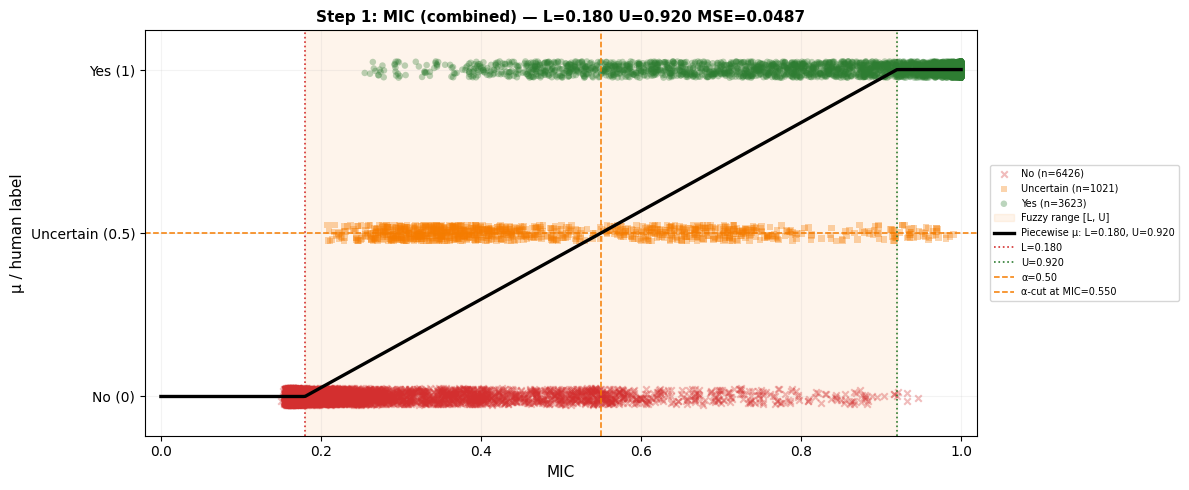

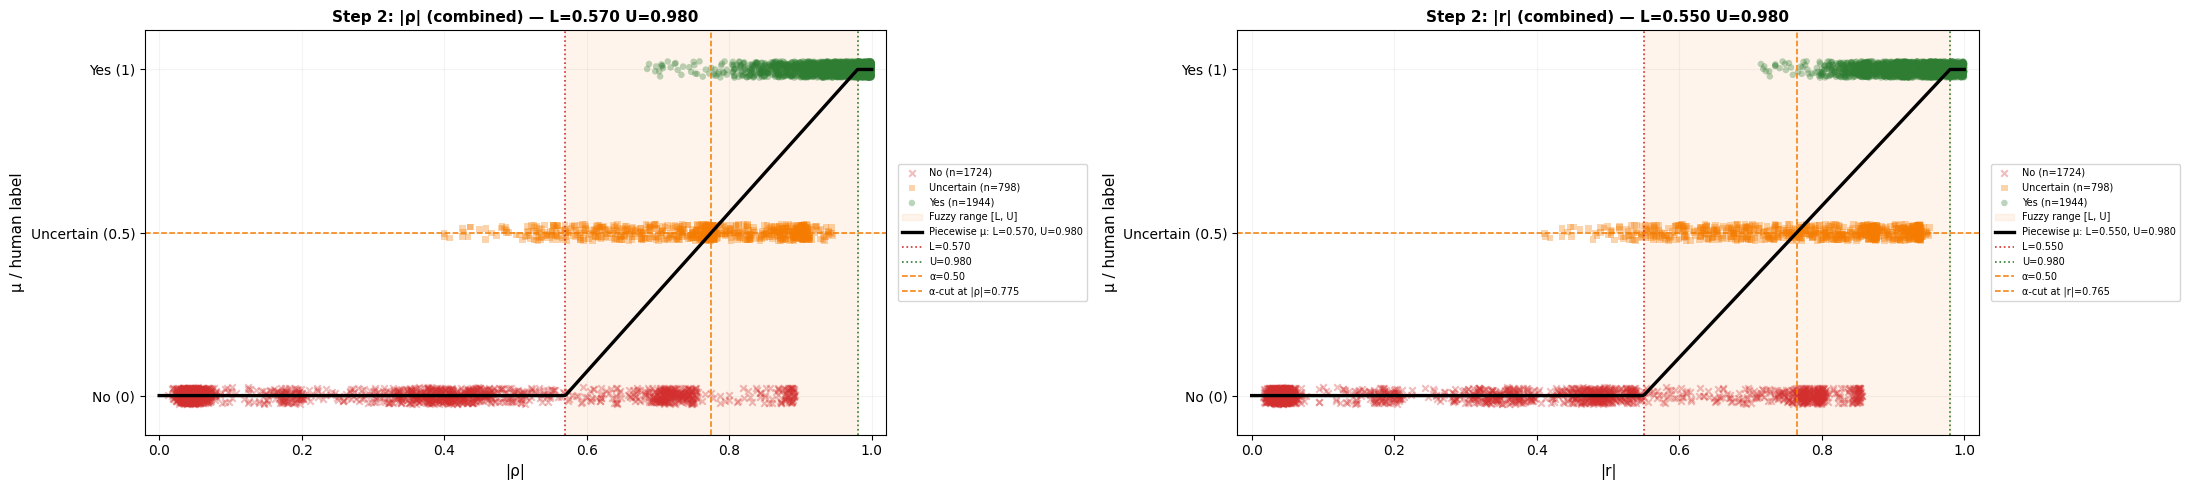

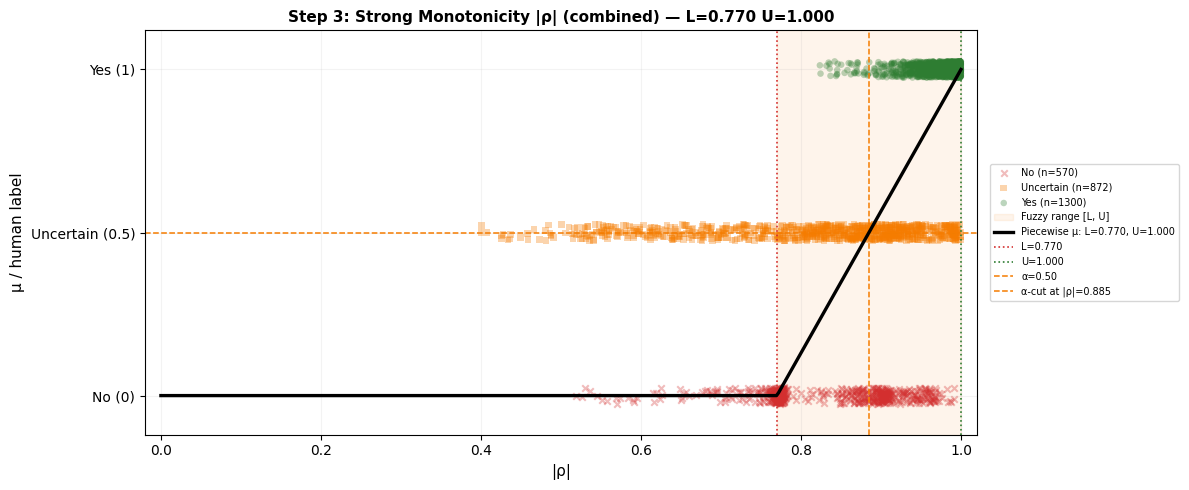

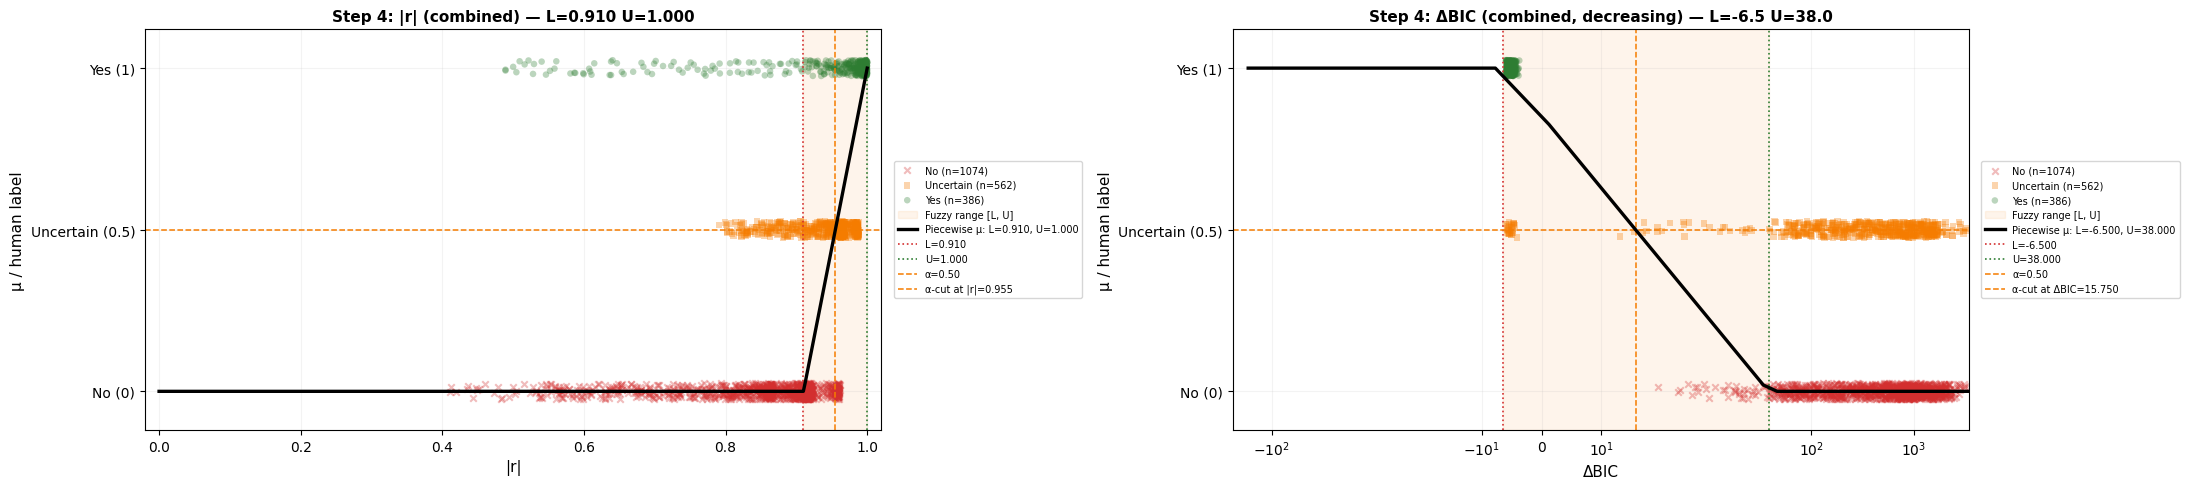

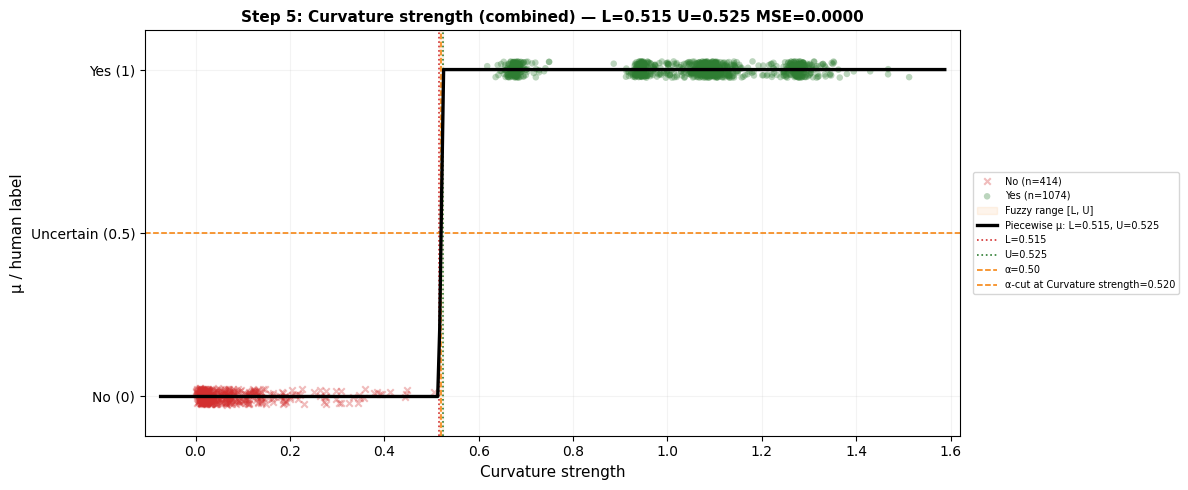

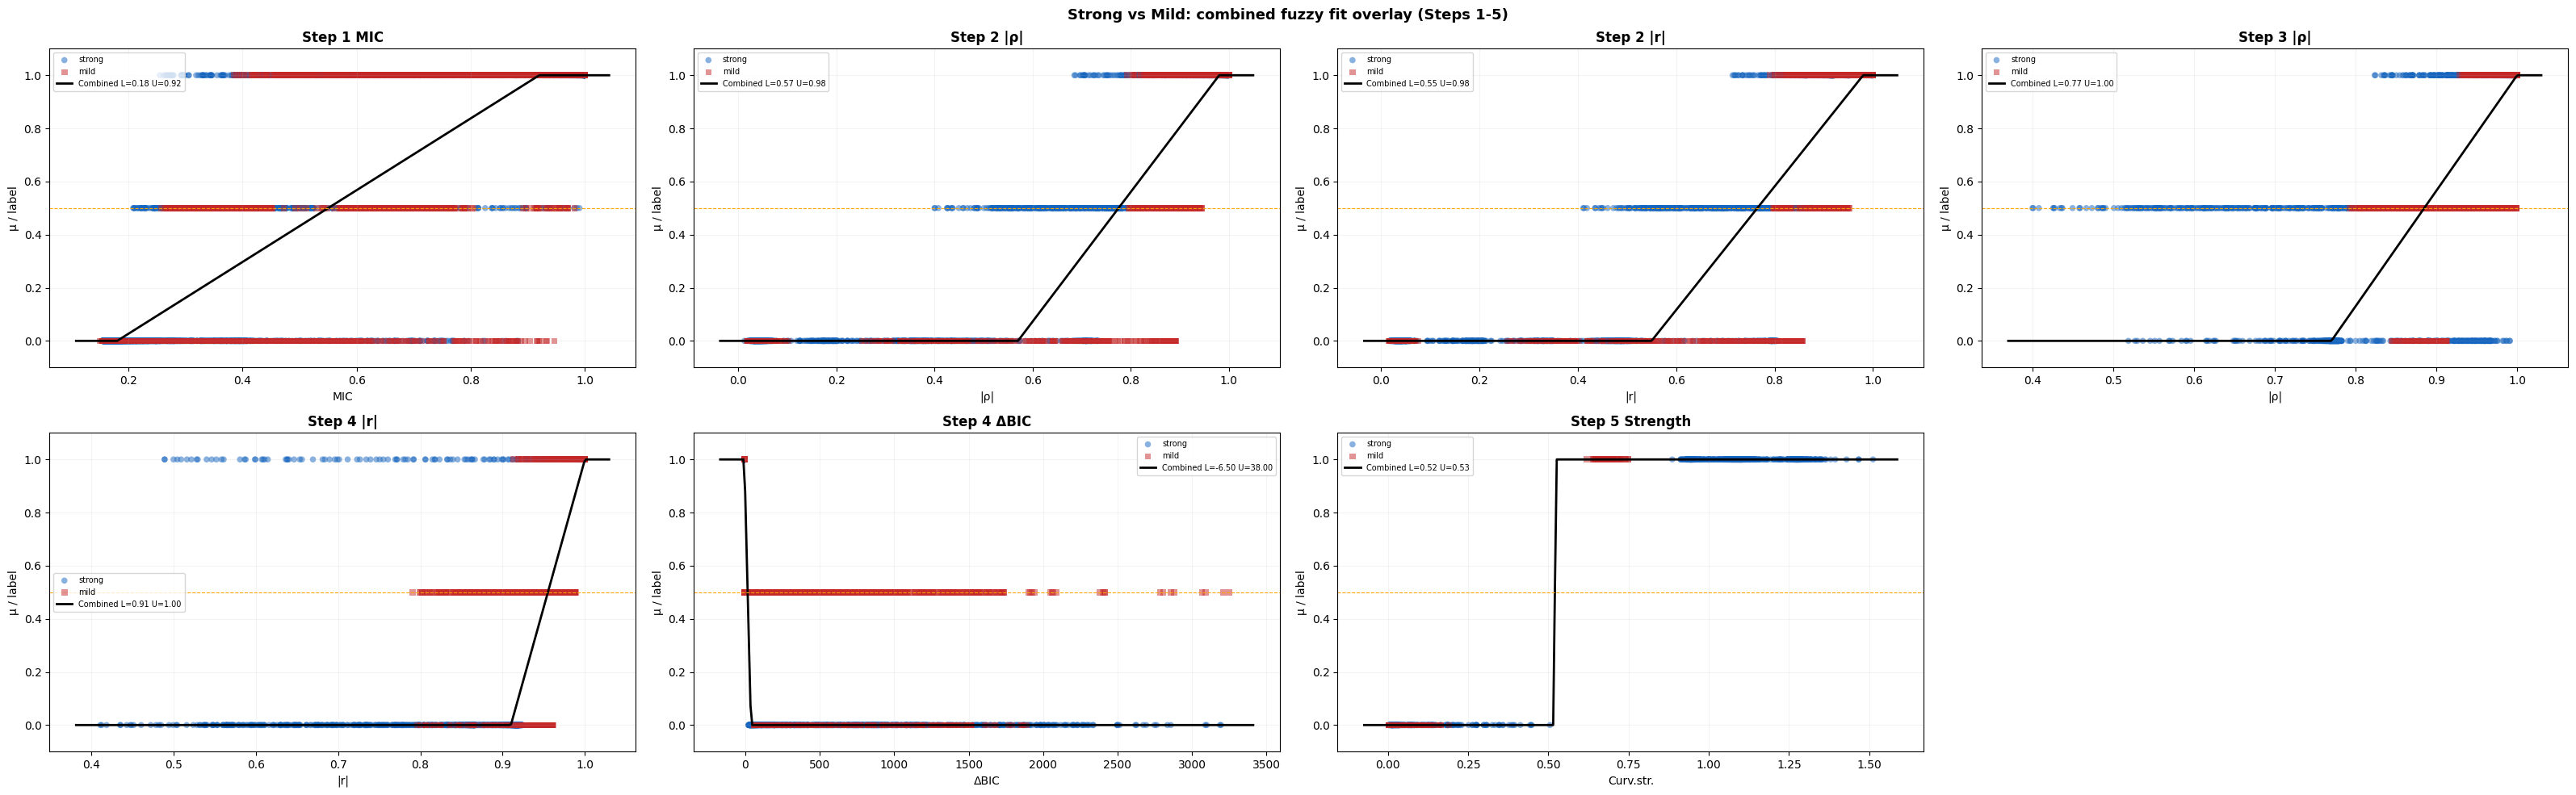

In [7]:
# ══════════════════════════════════════════════════════
#  Calibrated gate plots — combined training data
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# ── Step 1: MIC ──
fig, ax = plt.subplots(figsize=(12, 5))
r = results['step1_mic']
plot_calibrated_gate(ax,
    train['s1_mic']['indicator'].values, train['s1_mic']['label'].values,
    r['L'], r['U'], 'MIC',
    f'Step 1: MIC (combined) — L={r["L"]:.3f} U={r["U"]:.3f} MSE={r["mse"]:.4f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 2: |ρ| and |r| ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
r = results['step2_rho']
plot_calibrated_gate(ax1,
    train['s2_rho']['indicator'].values, train['s2_rho']['label'].values,
    r['L'], r['U'], '|ρ|',
    f'Step 2: |ρ| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
r = results['step2_r']
plot_calibrated_gate(ax2,
    train['s2_r']['indicator'].values, train['s2_r']['label'].values,
    r['L'], r['U'], '|r|',
    f'Step 2: |r| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 3: |ρ| ──
fig, ax = plt.subplots(figsize=(12, 5))
r = results['step3_rho']
plot_calibrated_gate(ax,
    train['s3_rho']['indicator'].values, train['s3_rho']['label'].values,
    r['L'], r['U'], '|ρ|',
    f'Step 3: Strong Monotonicity |ρ| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Step 4: |r| and ΔBIC ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
r = results['step4_r']
plot_calibrated_gate(ax1,
    train['s4_r']['indicator'].values, train['s4_r']['label'].values,
    r['L'], r['U'], '|r|',
    f'Step 4: |r| (combined) — L={r["L"]:.3f} U={r["U"]:.3f}',
    alpha=ALPHA, increasing=True)
r = results['step4_bic']
plot_calibrated_gate(ax2,
    train['s4_bic']['indicator'].values, train['s4_bic']['label'].values,
    r['L'], r['U'], 'ΔBIC',
    f'Step 4: ΔBIC (combined, decreasing) — L={r["L"]:.1f} U={r["U"]:.1f}',
    alpha=ALPHA, increasing=False)
_lt = max(abs(r['U']), 1.0)
ax2.set_xscale('symlog', linthresh=_lt, linscale=2.0)
plt.tight_layout()
plt.show()

# ── Step 5: curvature_strength only ──
fig, ax = plt.subplots(figsize=(12, 5))
r = results['step5_curved']
plot_calibrated_gate(ax,
    train['s5_cs']['indicator'].values, train['s5_cs']['label'].values,
    r['L'], r['U'], 'Curvature strength',
    f'Step 5: Curvature strength (combined) — L={r["L"]:.3f} U={r["U"]:.3f} MSE={r["mse"]:.4f}',
    alpha=ALPHA, increasing=True)
plt.tight_layout()
plt.show()

# ── Per-variant overlay: show strong vs mild on same axes ──
fig, axes = plt.subplots(2, 4, figsize=(32, 10))
gate_keys = [
    ('s1_mic',  'step1_mic',  'MIC',  'Step 1 MIC',  True),
    ('s2_rho',  'step2_rho',  '|ρ|',  'Step 2 |ρ|',  True),
    ('s2_r',    'step2_r',    '|r|',  'Step 2 |r|',  True),
    ('s3_rho',  'step3_rho',  '|ρ|',  'Step 3 |ρ|',  True),
    ('s4_r',    'step4_r',    '|r|',  'Step 4 |r|',  True),
    ('s4_bic',  'step4_bic',  'ΔBIC', 'Step 4 ΔBIC', False),
    ('s5_cs',   'step5_curved', 'Curv.str.', 'Step 5 Strength', True),
]
colors_v = {'strong': '#1565C0', 'mild': '#C62828'}
for idx, (tkey, rkey, xlab, title, increasing) in enumerate(gate_keys):
    ax = axes.flat[idx]
    r = results[rkey]
    t = train[tkey]

    for vname, color in colors_v.items():
        sub = t[t['variant'] == vname]
        marker = 'o' if vname == 'strong' else 's'
        ax.scatter(sub['indicator'], sub['label'],
                   c=color, marker=marker, s=30, alpha=0.5,
                   label=vname, edgecolors='none')

    lo, hi = t['indicator'].min(), t['indicator'].max()
    pad = 0.05 * max(hi - lo, 0.01)
    grid = np.linspace(lo - pad, hi + pad, 300)
    if increasing:
        mu = np.clip((grid - r['L']) / (r['U'] - r['L']), 0, 1)
    else:
        mu = 1.0 - np.clip((grid - r['L']) / (r['U'] - r['L']), 0, 1)
    ax.plot(grid, mu, 'k-', lw=2, label=f'Combined L={r["L"]:.2f} U={r["U"]:.2f}')
    ax.axhline(ALPHA, color='orange', ls='--', lw=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlab)
    ax.set_ylabel('μ / label')
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.15)

axes.flat[7].set_visible(False)
plt.suptitle('Strong vs Mild: combined fuzzy fit overlay (Steps 1-5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════
#  Comparison: combined vs individual fits
# ══════════════════════════════════════════════════════

old = {}
for tag, fname in [('strong', 'fuzzy_params.json'), ('mild', 'fuzzy_params_mild.json')]:
    p = OUT_DIR / fname
    if p.exists():
        with open(p) as f:
            old[tag] = json_mod.load(f)
        print(f'Loaded {tag} params from {fname}')
    else:
        print(f'{fname} not found — skip {tag} comparison')

gates = [
    ('Step 1 MIC',      'step1_mic',      'step1_mic'),
    ('Step 2 |ρ|',      'step2_rho',      'step2_rho'),
    ('Step 2 |r|',      'step2_r',        'step2_r'),
    ('Step 3 |ρ|',      'step3_rho',      'step3_rho'),
    ('Step 4 |r|',      'step4_r',        'step4_r'),
    ('Step 4 ΔBIC',     'step4_bic',      'step4_delta_bic'),
    ('Step 5 Strength', 'step5_curved',   'step5_curvature.curvature_strength'),
]

def get_nested(d, path):
    for key in path.split('.'):
        if key not in d: return None
        d = d[key]
    return d

rows = []
for label, res_key, old_key in gates:
    r = results[res_key]
    row = {'Gate': label,
           'Comb_L': round(r['L'], 3),
           'Comb_U': round(r['U'], 3),
           'Comb_MSE': round(r['mse'], 4)}
    for tag in ['strong', 'mild']:
        if tag in old:
            o = get_nested(old[tag], old_key)
            if o is not None:
                L_key = 'L_D' if 'L_D' in o else 'L'
                U_key = 'U_D' if 'U_D' in o else 'U'
                row[f'{tag}_L'] = round(o[L_key], 3)
                row[f'{tag}_U'] = round(o[U_key], 3)
                row[f'{tag}_MSE'] = round(o.get('mse', 0), 4)
    rows.append(row)

comp = pd.DataFrame(rows).set_index('Gate')
display(comp)

Loaded strong params from fuzzy_params.json
fuzzy_params_mild.json not found — skip mild comparison


,Comb_L,Comb_U,Comb_MSE,strong_L,strong_U,strong_MSE
Gate,,,,,,
Step 1 MIC,0.180,0.920,0.0487,0.180,0.880,0.0588
Step 2 |ρ|,0.570,0.980,0.0402,0.690,0.990,0.0516
Step 2 |r|,0.550,0.980,0.0527,0.700,0.990,0.0594
Step 3 |ρ|,0.770,1.000,0.0991,0.860,0.990,0.0544
Step 4 |r|,0.910,1.000,0.0987,0.920,0.990,0.1496
Step 4 ΔBIC,-6.500,38.000,0.0677,0.000,12.000,0.1651
Step 5 Strength,0.515,0.525,0.0000,0.251,0.264,0.0010


In [9]:
# ══════════════════════════════════════════════════════
#  Combined per-step success tables (both variants merged)
# ══════════════════════════════════════════════════════

DOMINANCE_THRESH = 0.75

all_eval = []
all_final = []

for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]
    curv_class = ann['CURVATURE_FAMILY_CLASS']

    ALL_FIDS = sorted(v['family_id'].unique())

    expected_s1_yes = set(ALL_FIDS) - set(ann['NO_GLOBAL']) - {'Null'}
    expected_s2_yes = set(ann['SIMPLE_FAM'] + ann['UNCERTAIN_S2'])
    expected_s3_yes = set(ann['STRONG_MONO'] + ann['UNCERTAIN_MONO'])
    expected_s4_line = set(ann['LINEAR_FAM'])
    expected_s4_nonline = set(ann['NONLINEAR_FAM'])

    mic_vals = v['MIC'].values
    mu_s1 = fuzzy_mu(mic_vals, results['step1_mic']['L'], results['step1_mic']['U'])
    pred_s1_pass = mu_s1 >= ALPHA

    rho_vals = v['abs_rho'].values
    r_vals   = v['abs_r'].values
    mu_s2_rho = fuzzy_mu(rho_vals, results['step2_rho']['L'], results['step2_rho']['U'])
    mu_s2_r   = fuzzy_mu(r_vals, results['step2_r']['L'], results['step2_r']['U'])
    mu_s2 = np.minimum(mu_s2_rho, mu_s2_r)
    pred_s2_pass = pred_s1_pass & (mu_s2 >= ALPHA)

    mu_s3 = fuzzy_mu(rho_vals, results['step3_rho']['L'], results['step3_rho']['U'])
    pred_s3_pass = pred_s2_pass & (mu_s3 >= ALPHA)

    mu_s4_r = fuzzy_mu(r_vals, results['step4_r']['L'], results['step4_r']['U'])
    bic_vals = v['delta_bic'].values
    mu_s4_bic = 1.0 - fuzzy_mu(bic_vals, results['step4_bic']['L'], results['step4_bic']['U'])
    mu_s4_line = np.minimum(mu_s4_r, mu_s4_bic)
    pred_s4_line = pred_s3_pass & (mu_s4_line >= ALPHA)
    pred_s4_nonline = pred_s3_pass & ~pred_s4_line

    # Step 5: ONE fuzzy gate (curvature_strength), then direct f'' sign classification
    cs_vals = v['curvature_strength'].values
    dom_vals = v['f2_dominance'].values
    sign_vals = v['f2_dom_sign'].values
    mu_curved = fuzzy_mu(cs_vals, results['step5_curved']['L'], results['step5_curved']['U'])

    pred_s5 = pd.Series('', index=v.index)
    s5_enter = pred_s4_nonline & np.isfinite(cs_vals)
    curved_enough = s5_enter & (mu_curved >= ALPHA)
    pred_s5[s5_enter & ~curved_enough] = 'Curvature uncertain'
    # Direct sign classification: f2_dominance >= threshold → use sign, else Inflected
    const_curv = curved_enough & (dom_vals >= DOMINANCE_THRESH)
    pred_s5[const_curv & (sign_vals > 0)] = 'Convex'
    pred_s5[const_curv & (sign_vals <= 0)] = 'Concave'
    pred_s5[curved_enough & (dom_vals < DOMINANCE_THRESH)] = 'Inflected'

    eval_df = v[['case_id', 'family_id']].copy()
    eval_df['variant'] = vname
    eval_df['expected_s1'] = eval_df['family_id'].isin(expected_s1_yes)
    eval_df['correct_s1'] = pred_s1_pass == eval_df['expected_s1'].values

    eval_df['enter_s2'] = eval_df['correct_s1'] & eval_df['expected_s1'] & pred_s1_pass
    eval_df['expected_s2'] = eval_df['family_id'].isin(expected_s2_yes)
    eval_df['correct_s2'] = eval_df['enter_s2'] & (pred_s2_pass == eval_df['expected_s2'].values)

    eval_df['enter_s3'] = eval_df['correct_s2'] & eval_df['expected_s2'] & pred_s2_pass
    eval_df['expected_s3'] = eval_df['family_id'].isin(expected_s3_yes)
    eval_df['correct_s3'] = eval_df['enter_s3'] & (pred_s3_pass == eval_df['expected_s3'].values)

    eval_df['enter_s4'] = eval_df['correct_s3'] & eval_df['expected_s3'] & pred_s3_pass
    eval_df['expected_s4_line'] = eval_df['family_id'].isin(expected_s4_line)
    eval_df['correct_s4'] = eval_df['enter_s4'] & (pred_s4_line == eval_df['expected_s4_line'].values)

    eval_df['enter_s5'] = (eval_df['correct_s4']
                           & eval_df['family_id'].isin(set(curv_class.keys()))
                           & ~pred_s4_line)
    eval_df['pred_s5'] = pred_s5
    eval_df['expected_s5'] = eval_df['family_id'].map(curv_class)
    eval_df['correct_s5'] = eval_df['enter_s5'] & (pred_s5 == eval_df['expected_s5'].values)
    eval_df['enter_s1'] = True

    all_eval.append(eval_df)

    # Final prediction
    final = v[['case_id', 'family_id']].copy()
    final['variant'] = vname
    final['prediction'] = 'Unresolved'
    final.loc[~pred_s1_pass, 'prediction'] = 'No global'
    final.loc[pred_s1_pass & ~pred_s2_pass, 'prediction'] = 'Complex'
    final.loc[pred_s2_pass & ~pred_s3_pass, 'prediction'] = 'Weak mono'
    final.loc[pred_s4_line, 'prediction'] = 'Line'
    s5_has = pred_s5 != ''
    final.loc[s5_has, 'prediction'] = pred_s5[s5_has]

    EXPECTED_FINAL = {
        **{fid: 'No global' for fid in list(ann['NO_GLOBAL']) + ['Null']},
        **{fid: 'Complex' for fid in ann['COMPLEX_FAM']},
        **{fid: 'Weak mono' for fid in ann['WEAK_MONO']},
        **{fid: 'Line' for fid in ann['LINEAR_FAM']},
        **curv_class,
    }
    final['expected'] = final['family_id'].map(EXPECTED_FINAL)
    final['correct'] = final['prediction'] == final['expected']
    all_final.append(final)

# ── Stack both variants ──
eval_all = pd.concat(all_eval, ignore_index=True)
final_all = pd.concat(all_final, ignore_index=True)

# ── Build combined per-step tables ──
# For combined: group by (variant, family_id) so each variant's families get their own expected labels
print(f'\n{"="*60}')
print(f'  COMBINED — Per-step success (both variants)')
print(f'{"="*60}')

for step in range(1, 6):
    enter_col = f'enter_s{step}' if step > 0 else 'enter_s1'
    correct_col = f'correct_s{step}'
    sub = eval_all[eval_all[enter_col]]
    if len(sub) == 0:
        print(f'\n  Step {step} — no rows entered')
        continue

    tbl = sub.groupby(['variant', 'family_id']).agg(
        entered=(enter_col, 'sum'),
        correct=(correct_col, 'sum'),
    ).reset_index()
    tbl['rate'] = np.where(tbl['entered'] > 0, tbl['correct'] / tbl['entered'], np.nan)

    if step == 5:
        tbl['expected'] = tbl.apply(
            lambda r: ANNOT[r['variant']]['CURVATURE_FAMILY_CLASS'].get(r['family_id'], '?'), axis=1)
    elif step == 4:
        def s4_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['LINEAR_FAM']: return 'Line'
            if r['family_id'] in ann['NONLINEAR_FAM']: return 'Non-line'
            return '?'
        tbl['expected'] = tbl.apply(s4_cat, axis=1)
    elif step == 3:
        def s3_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['STRONG_MONO'] + ann['UNCERTAIN_MONO']: return 'Strong/Unc mono'
            if r['family_id'] in ann['WEAK_MONO']: return 'Weak'
            return '?'
        tbl['expected'] = tbl.apply(s3_cat, axis=1)
    elif step == 2:
        def s2_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['SIMPLE_FAM'] + ann['UNCERTAIN_S2']: return 'Simple/Unc'
            if r['family_id'] in ann['COMPLEX_FAM']: return 'Complex'
            return '?'
        tbl['expected'] = tbl.apply(s2_cat, axis=1)
    else:
        def s1_cat(r):
            ann = ANNOT[r['variant']]
            if r['family_id'] in ann['NO_GLOBAL'] or r['family_id'] == 'Null': return 'No global'
            return 'Global'
        tbl['expected'] = tbl.apply(s1_cat, axis=1)

    tbl = tbl.sort_values(['variant', 'family_id'])
    total_entered = int(tbl['entered'].sum())
    total_correct = int(tbl['correct'].sum())
    overall_rate = total_correct / total_entered if total_entered > 0 else 0

    print(f'\n  Step {step} — {total_correct}/{total_entered} correct ({overall_rate:.1%})')
    tbl_display = tbl.copy()
    tbl_display['rate'] = tbl_display['rate'].map(lambda x: f'{x:.1%}' if pd.notna(x) else 'N/A')
    display(tbl_display.set_index(['variant', 'family_id']))

# ── Final combined classification table ──
ftbl = final_all.dropna(subset=['expected']).groupby(['variant', 'family_id']).agg(
    n=('case_id', 'size'),
    correct=('correct', 'sum'),
    top_pred=('prediction', lambda s: s.value_counts().index[0]),
).reset_index()
ftbl['rate'] = ftbl['correct'] / ftbl['n']
ftbl['expected'] = ftbl.apply(
    lambda r: {
        **{fid: 'No global' for fid in list(ANNOT[r['variant']]['NO_GLOBAL']) + ['Null']},
        **{fid: 'Complex' for fid in ANNOT[r['variant']]['COMPLEX_FAM']},
        **{fid: 'Weak mono' for fid in ANNOT[r['variant']]['WEAK_MONO']},
        **{fid: 'Line' for fid in ANNOT[r['variant']]['LINEAR_FAM']},
        **ANNOT[r['variant']]['CURVATURE_FAMILY_CLASS'],
    }.get(r['family_id'], '?'), axis=1)
ftbl = ftbl.sort_values(['variant', 'family_id'])

total_n = int(ftbl['n'].sum())
total_c = int(ftbl['correct'].sum())
print(f'\n{"="*60}')
print(f'  Final classification — {total_c}/{total_n} correct ({total_c/total_n:.1%})')
print(f'{"="*60}')
ftbl_d = ftbl.copy()
ftbl_d['rate'] = ftbl_d['rate'].map(lambda x: f'{x:.1%}')
display(ftbl_d.set_index(['variant', 'family_id']))


  COMBINED — Per-step success (both variants)

  Step 1 — 52546/110700 correct (47.5%)


entered  correct    rate   expected
variant family_id                                     
mild    F01           2050      958   46.7%     Global
        F02           2050      957   46.7%     Global
        F03           2050      935   45.6%     Global
        F04           2050      927   45.2%     Global
        F05           2050      927   45.2%     Global
        F06           2050      933   45.5%     Global
        F07           2050      894   43.6%     Global
        F08           2050      894   43.6%     Global
        F09           2050      907   44.2%     Global
        F10           2050      909   44.3%     Global
        F11           2050      917   44.7%     Global
        F12           2050      922   45.0%     Global
        F13           2050      988   48.2%     Global
        F14           2050      986   48.1%     Global
        F15           2050     1002   48.9%     Global
        F16           2050     1012   49.4%     Global
        F17           2050      913   44.5%     Global
        F18           2050      916   44.7%     Global
        F19           2050     1773   86.5%  No global
        F20           2050     1792   87.4%  No global
        F21           2050      720   35.1%     Global
        F22           2050      977   47.7%     Global
        F23           2050      810   39.5%     Global
        F24           2050      253   12.3%     Global
        F25           2050      567   27.7%     Global
        F26           2050      471   23.0%     Global
        Null          2050     2050  100.0%  No global
strong  F01           2050      962   46.9%     Global
        F02           2050      954   46.5%     Global
        F03           2050      860   42.0%     Global
        F04           2050      854   41.7%     Global
        F05           2050      876   42.7%     Global
        F06           2050      868   42.3%     Global
        F07           2050     1481   72.2%  No global
        F08           2050     1490   72.7%  No global
        F09           2050      868   42.3%     Global
        F10           2050      862   42.0%     Global
        F11           2050      872   42.5%     Global
        F12           2050      866   42.2%     Global
        F13           2050     1011   49.3%     Global
        F14           2050     1004   49.0%     Global
        F15           2050     1027   50.1%     Global
        F16           2050     1020   49.8%     Global
        F17           2050      914   44.6%     Global
        F18           2050      917   44.7%     Global
        F19           2050     2050  100.0%  No global
        F20           2050     2050  100.0%  No global
        F21           2050      721   35.2%     Global
        F22           2050      948   46.2%     Global
        F23           2050      351   17.1%     Global
        F24           2050      289   14.1%     Global
        F25           2050       66    3.2%     Global
        F26           2050        5    0.2%     Global
        Null          2050     2050  100.0%  No global


  Step 2 — 32820/37810 correct (86.8%)


entered  correct    rate    expected
variant family_id                                      
mild    F01            958      945   98.6%  Simple/Unc
        F02            957      945   98.7%  Simple/Unc
        F03            935      911   97.4%  Simple/Unc
        F04            927      914   98.6%  Simple/Unc
        F05            927      924   99.7%  Simple/Unc
        F06            933      929   99.6%  Simple/Unc
        F07            894       21    2.3%           ?
        F08            894       19    2.1%           ?
        F09            907      900   99.2%  Simple/Unc
        F10            909      903   99.3%  Simple/Unc
        F11            917      904   98.6%  Simple/Unc
        F12            922      908   98.5%  Simple/Unc
        F13            988      933   94.4%  Simple/Unc
        F14            986      930   94.3%  Simple/Unc
        F15           1002      889   88.7%  Simple/Unc
        F16           1012      895   88.4%  Simple/Unc
        F17            913      913  100.0%     Complex
        F18            916      916  100.0%     Complex
        F21            720      702   97.5%     Complex
        F22            977      958   98.1%     Complex
        F23            810       30    3.7%     Complex
        F24            253      253  100.0%     Complex
        F25            567      567  100.0%     Complex
        F26            471      471  100.0%     Complex
strong  F01            962      942   97.9%  Simple/Unc
        F02            954      945   99.1%  Simple/Unc
        F03            860      754   87.7%  Simple/Unc
        F04            854      739   86.5%  Simple/Unc
        F05            876      864   98.6%  Simple/Unc
        F06            868      862   99.3%  Simple/Unc
        F09            868      862   99.3%  Simple/Unc
        F10            862      855   99.2%  Simple/Unc
        F11            872      845   96.9%  Simple/Unc
        F12            866      846   97.7%  Simple/Unc
        F13           1011      911   90.1%  Simple/Unc
        F14           1004      913   90.9%  Simple/Unc
        F15           1027      307   29.9%  Simple/Unc
        F16           1020      302   29.6%  Simple/Unc
        F17            914      914  100.0%     Complex
        F18            917      917  100.0%     Complex
        F21            721      703   97.5%     Complex
        F22            948      948  100.0%     Complex
        F23            351      351  100.0%     Complex
        F24            289      289  100.0%     Complex
        F25             66       66  100.0%     Complex
        F26              5        5  100.0%     Complex


  Step 3 — 17993/23777 correct (75.7%)


...

entered  correct    rate  expected
variant family_id                                    
mild    F01            817      641   78.5%      Line
        F02            813      648   79.7%      Line
        F03            756      756  100.0%         ?
        F04            755      755  100.0%         ?
        F05            794      794  100.0%         ?
        F06            797      797  100.0%         ?
        F09            760      760  100.0%  Non-line
        F10            755      755  100.0%  Non-line
        F11            765      765  100.0%         ?
        F12            752      752  100.0%         ?
        F13            776      776  100.0%         ?
        F14            787      787  100.0%         ?
strong  F01            813      645   79.3%      Line
        F02            812      641   78.9%      Line
        F03            477      477  100.0%  Non-line
        F04            481      481  100.0%  Non-line
        F05            713      713  100.0%  Non-line
        F06            718      718  100.0%  Non-line
        F09            707      707  100.0%  Non-line
        F10            701      701  100.0%  Non-line
        F11            657      657  100.0%  Non-line
        F12            668      668  100.0%  Non-line


  Step 5 — 6637/6637 correct (100.0%)


entered  correct    rate expected
variant family_id                                   
mild    F09            760      760  100.0%  Concave
        F10            755      755  100.0%   Convex
strong  F03            477      477  100.0%   Convex
        F04            481      481  100.0%  Concave
        F05            713      713  100.0%  Concave
        F06            718      718  100.0%   Convex
        F09            707      707  100.0%  Concave
        F10            701      701  100.0%   Convex
        F11            657      657  100.0%   Convex
        F12            668      668  100.0%  Concave


  Final classification — 34587/94300 correct (36.7%)


n  correct   top_pred    rate   expected
variant family_id                                             
mild    F01        2050      641  No global   31.3%       Line
        F02        2050      648  No global   31.6%       Line
        F07        2050        0  No global    0.0%     Convex
        F08        2050        0  No global    0.0%    Concave
        F09        2050      760  No global   37.1%    Concave
        F10        2050      755  No global   36.8%     Convex
        F15        2050      391  No global   19.1%  Weak mono
        F16        2050      399  No global   19.5%  Weak mono
        F17        2050      913  No global   44.5%    Complex
        F18        2050      916  No global   44.7%    Complex
        F19        2050     1773  No global   86.5%  No global
        F20        2050     1792  No global   87.4%  No global
        F21        2050      702  No global   34.2%    Complex
        F22        2050      958  No global   46.7%    Complex
        F23        2050        0  No global    0.0%       Line
        F24        2050        0  No global    0.0%       Line
        F25        2050      567  No global   27.7%    Complex
        F26        2050      471  No global   23.0%    Complex
        Null       2050     2050  No global  100.0%  No global
strong  F01        2050      645  No global   31.5%       Line
        F02        2050      641  No global   31.3%       Line
        F03        2050      477  No global   23.3%     Convex
        F04        2050      481  No global   23.5%    Concave
        F05        2050      713  No global   34.8%    Concave
        F06        2050      718  No global   35.0%     Convex
        F07        2050     1481  No global   72.2%  No global
        F08        2050     1490  No global   72.7%  No global
        F09        2050      707  No global   34.5%    Concave
        F10        2050      701  No global   34.2%     Convex
        F11        2050      657  No global   32.0%     Convex
        F12        2050      668  No global   32.6%    Concave
        F13        2050      258  No global   12.6%  Weak mono
        F14        2050      262  No global   12.8%  Weak mono
        F15        2050      307  No global   15.0%  Weak mono
        F16        2050      302  No global   14.7%  Weak mono
        F17        2050      914  No global   44.6%    Complex
        F18        2050      917  No global   44.7%    Complex
        F19        2050     2050  No global  100.0%  No global
        F20        2050     2050  No global  100.0%  No global
        F21        2050      703  No global   34.3%    Complex
        F22        2050      948  No global   46.2%    Complex
        F23        2050      351  No global   17.1%    Complex
        F24        2050      289  No global   14.1%    Complex
        F25        2050       66  No global    3.2%    Complex
        F26        2050        5  No global    0.2%    Complex
        Null       2050     2050  No global  100.0%  No global

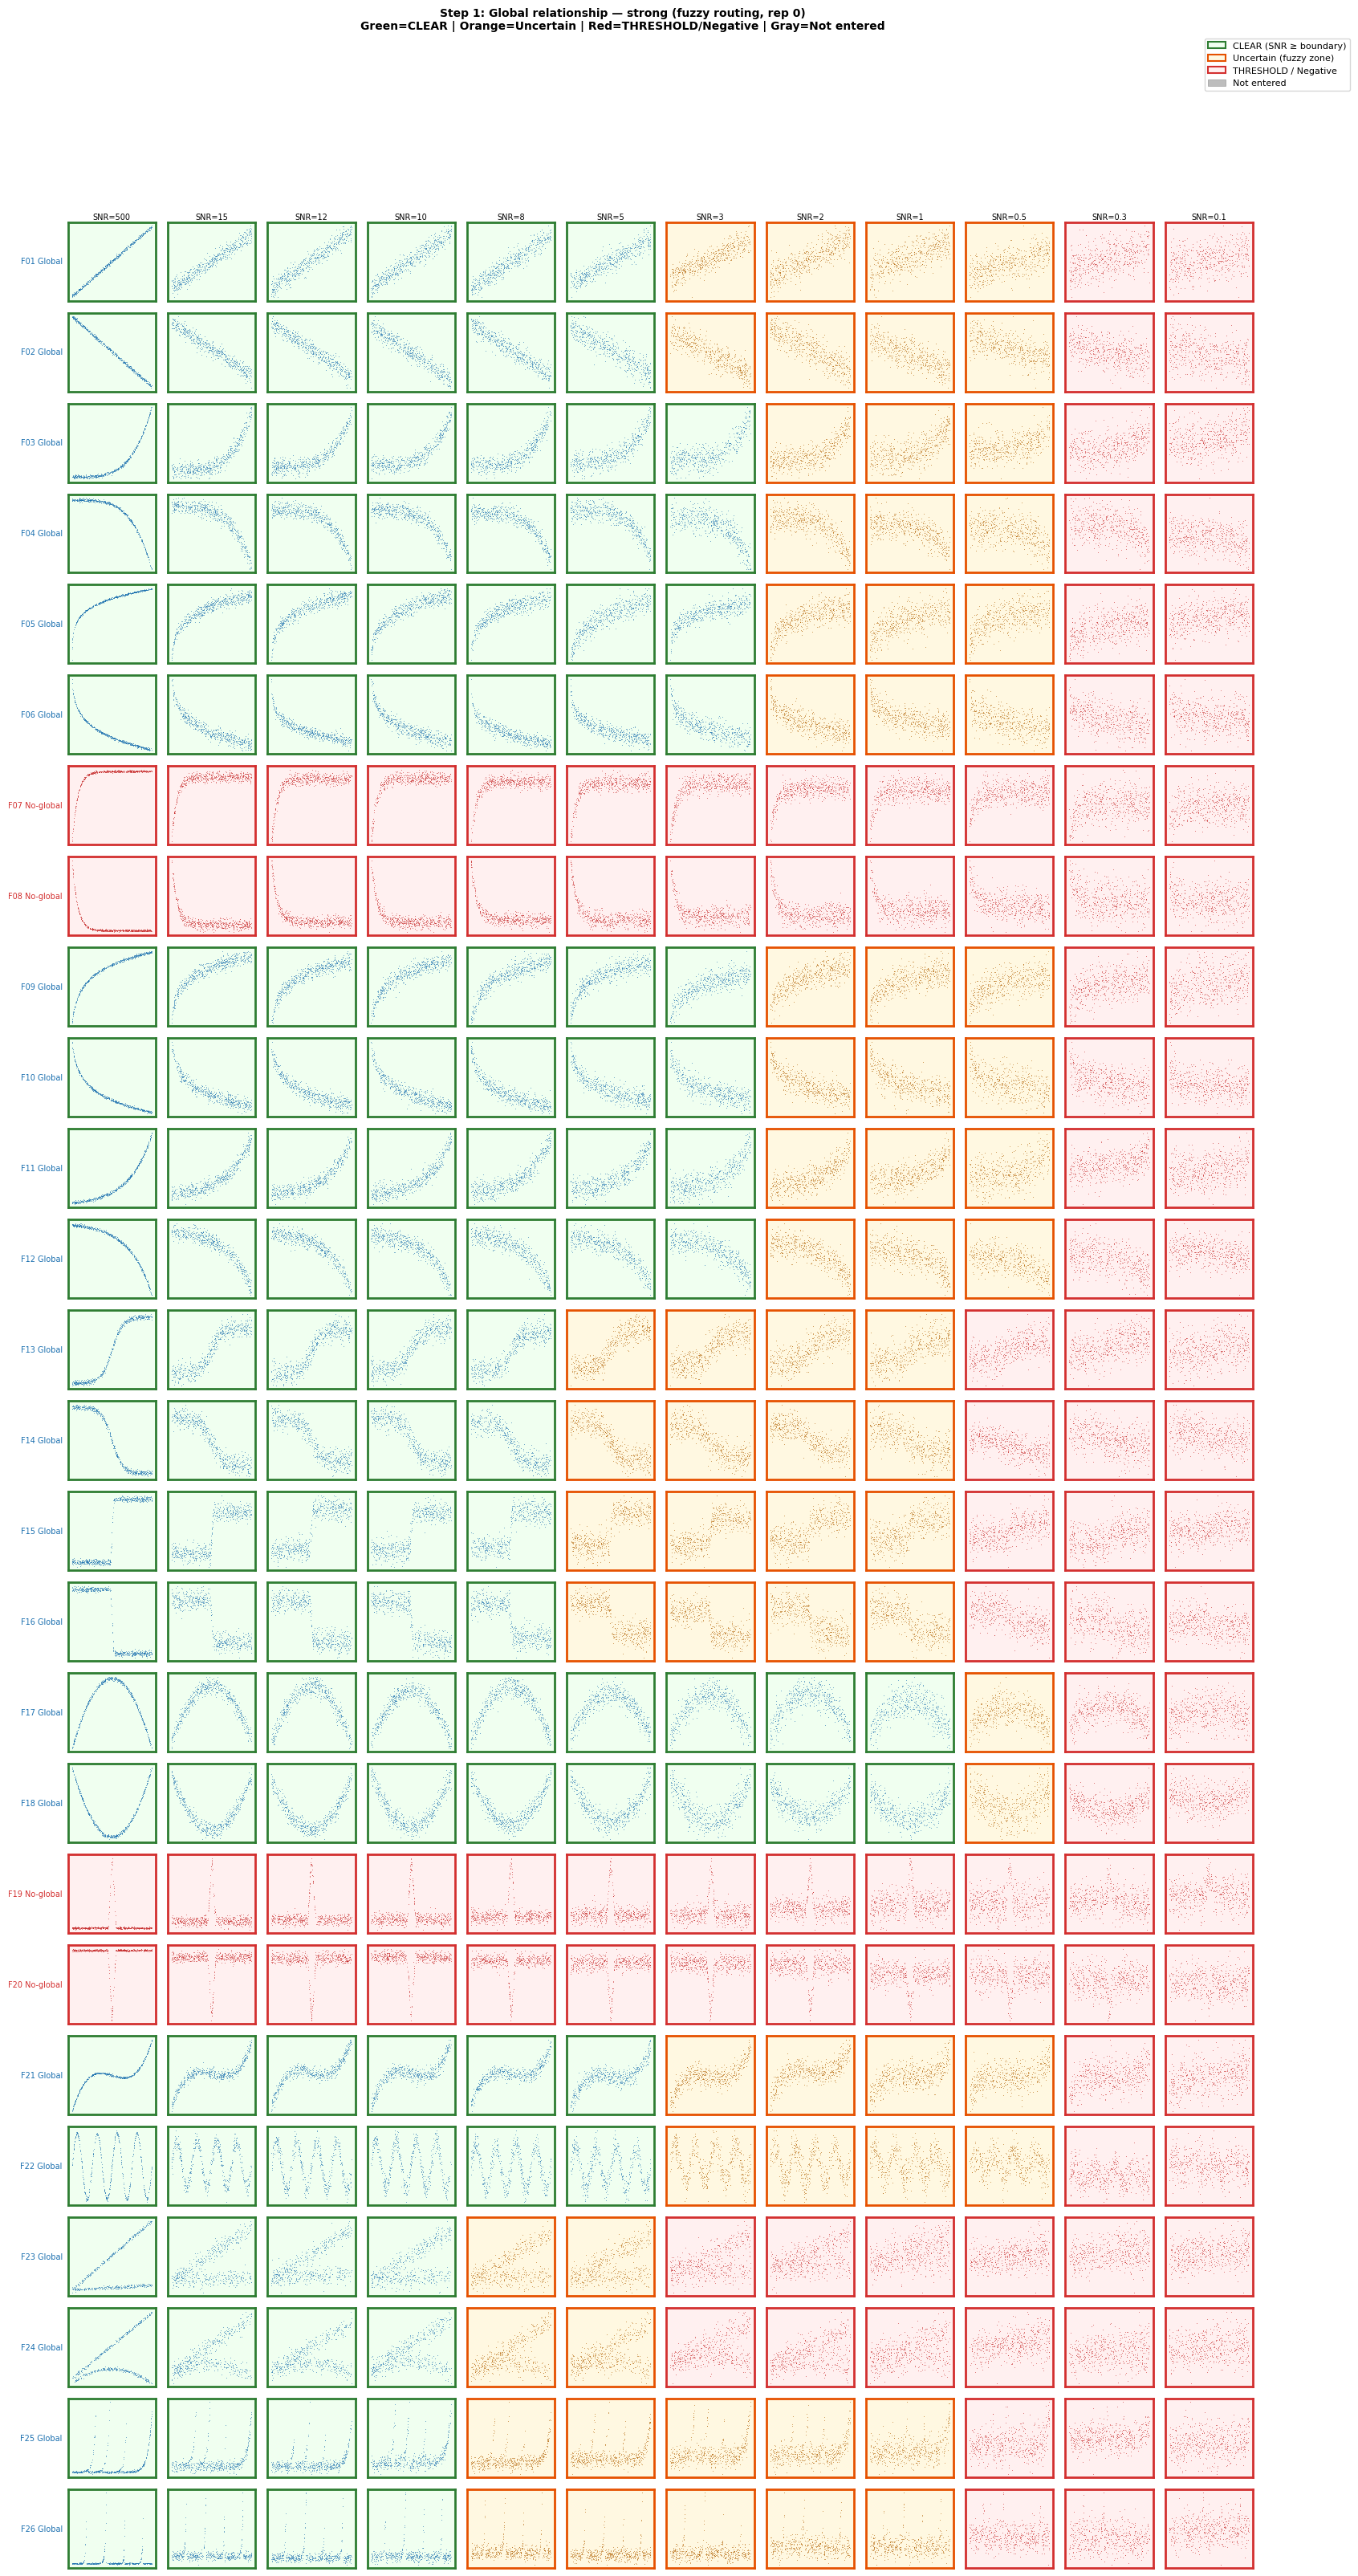

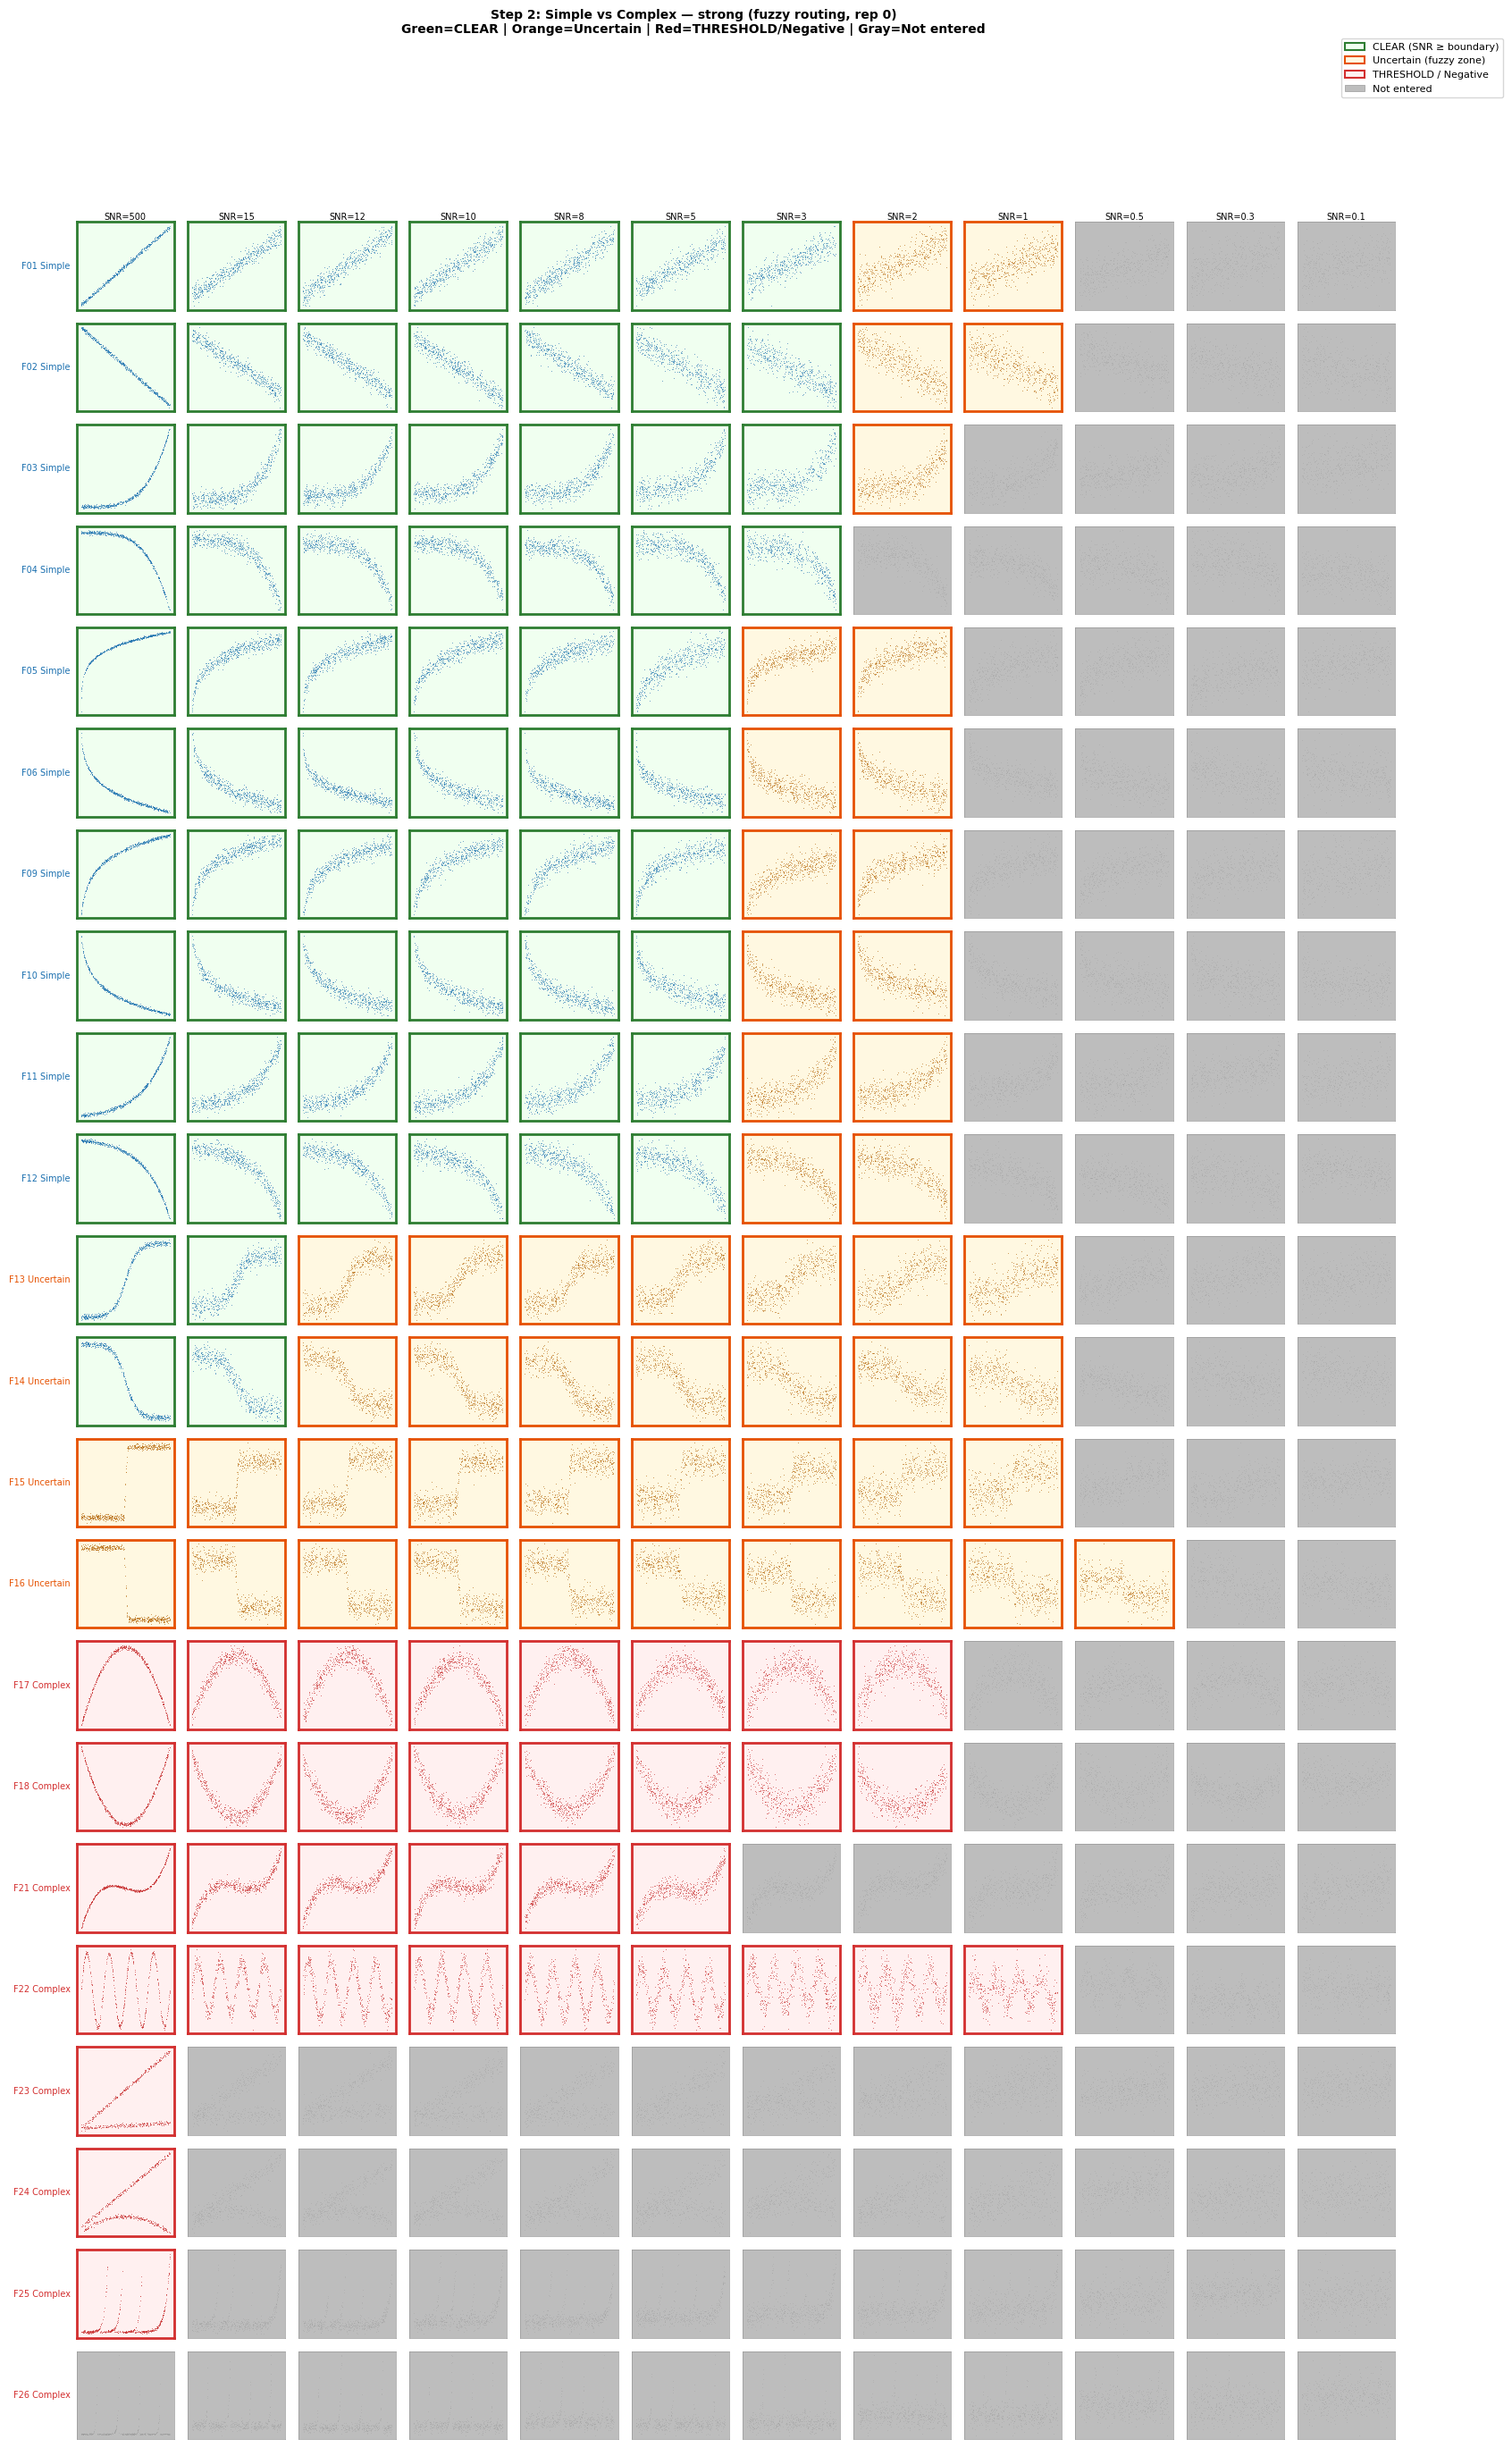

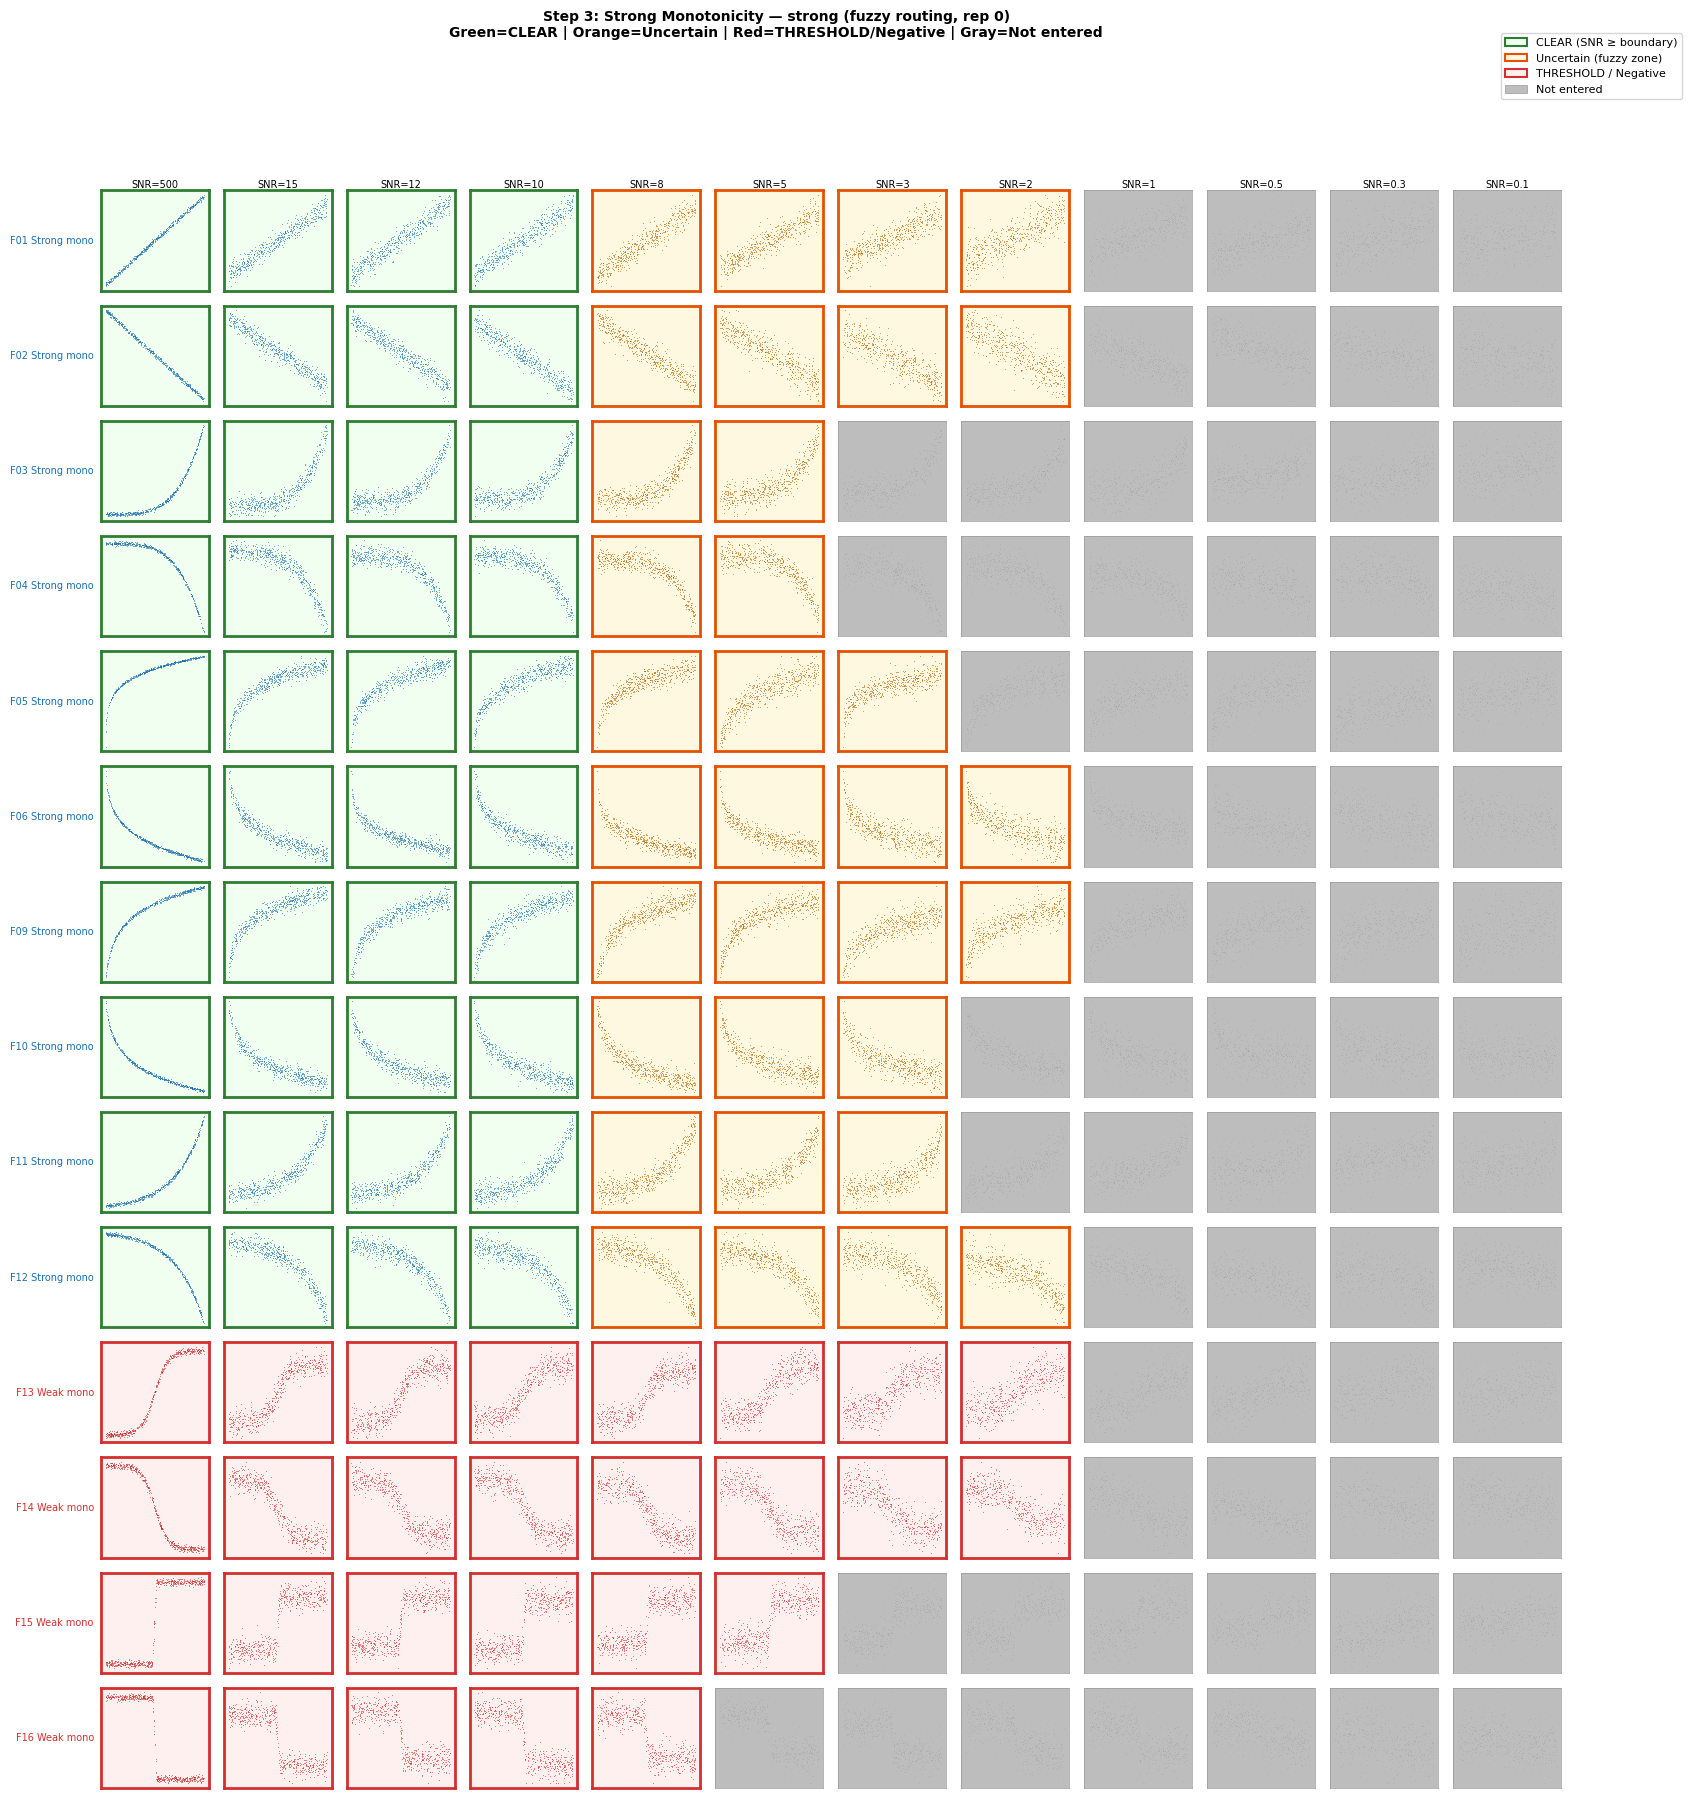

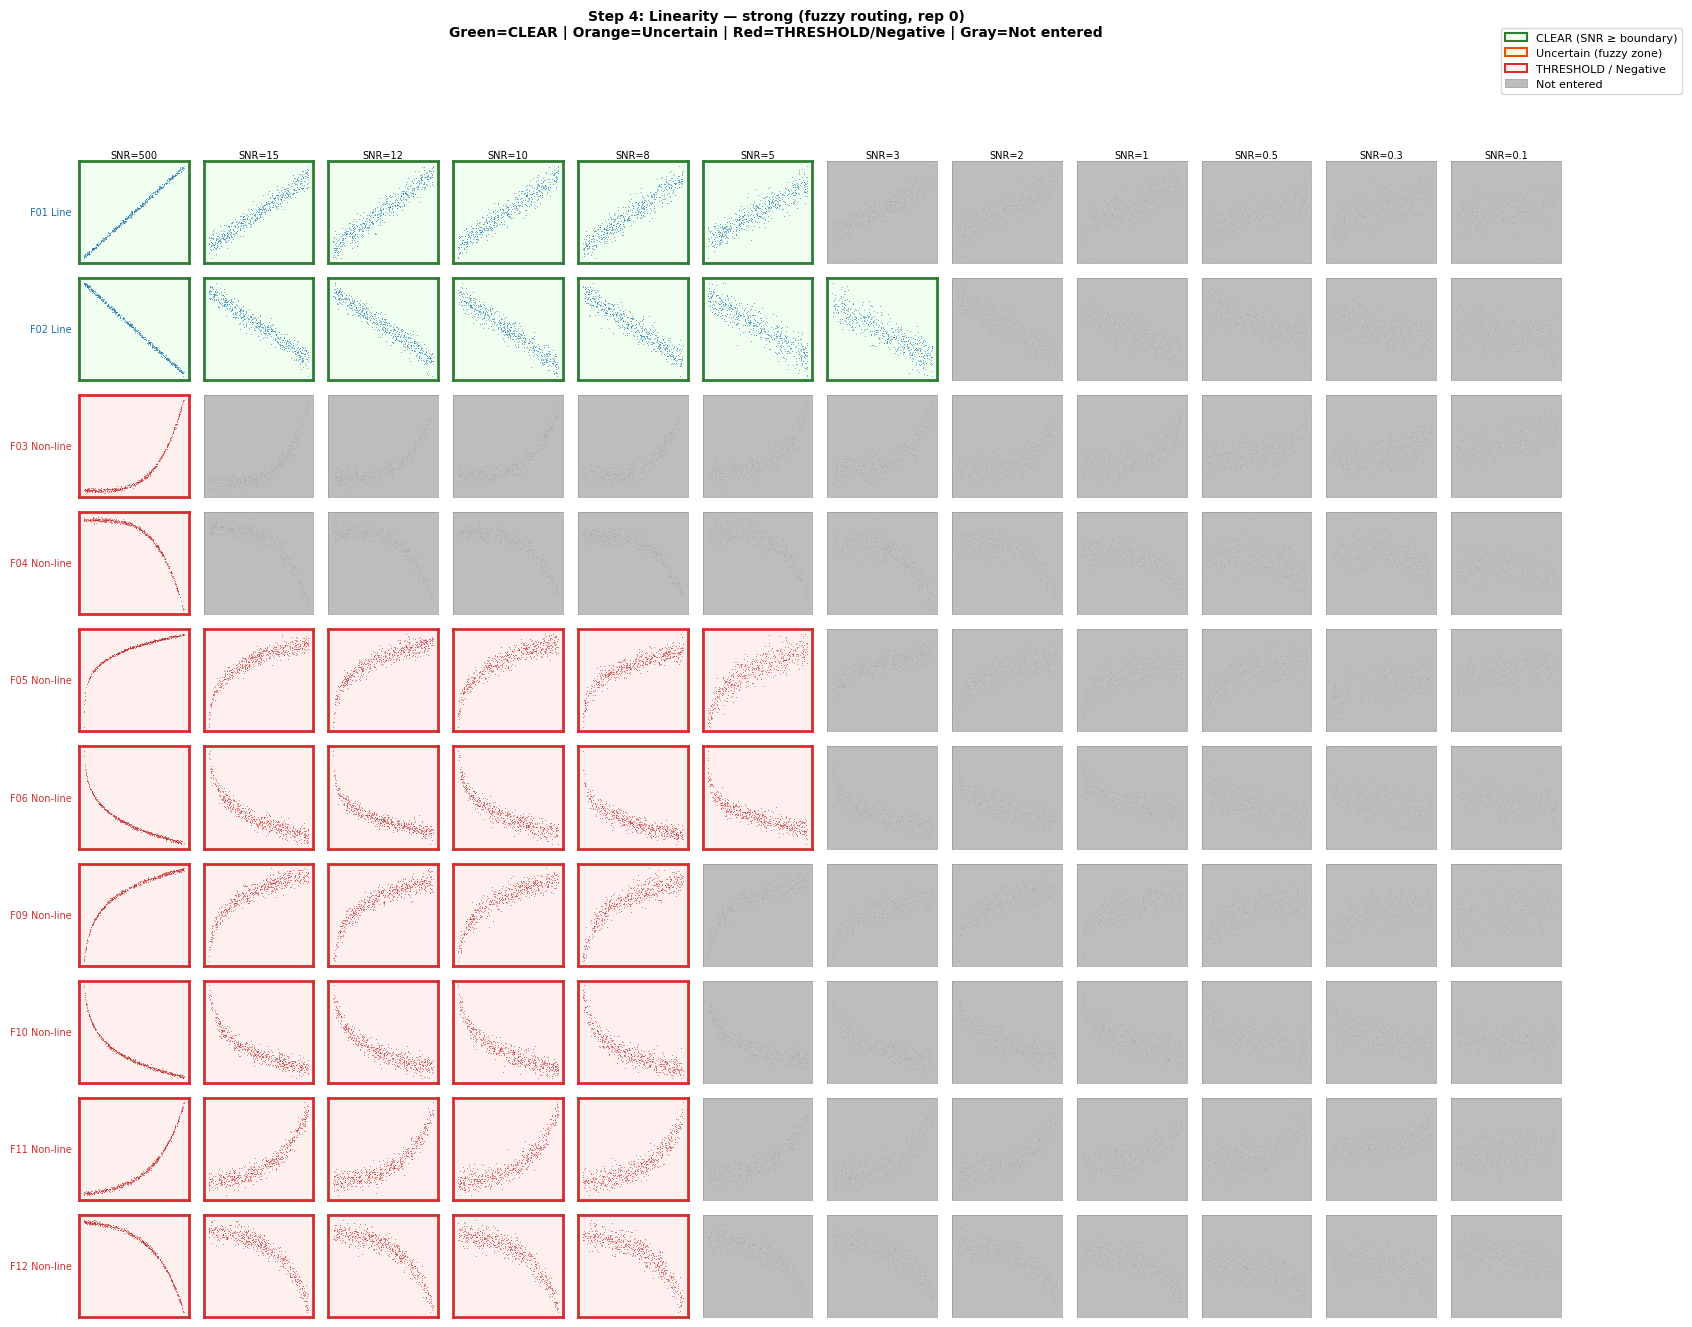

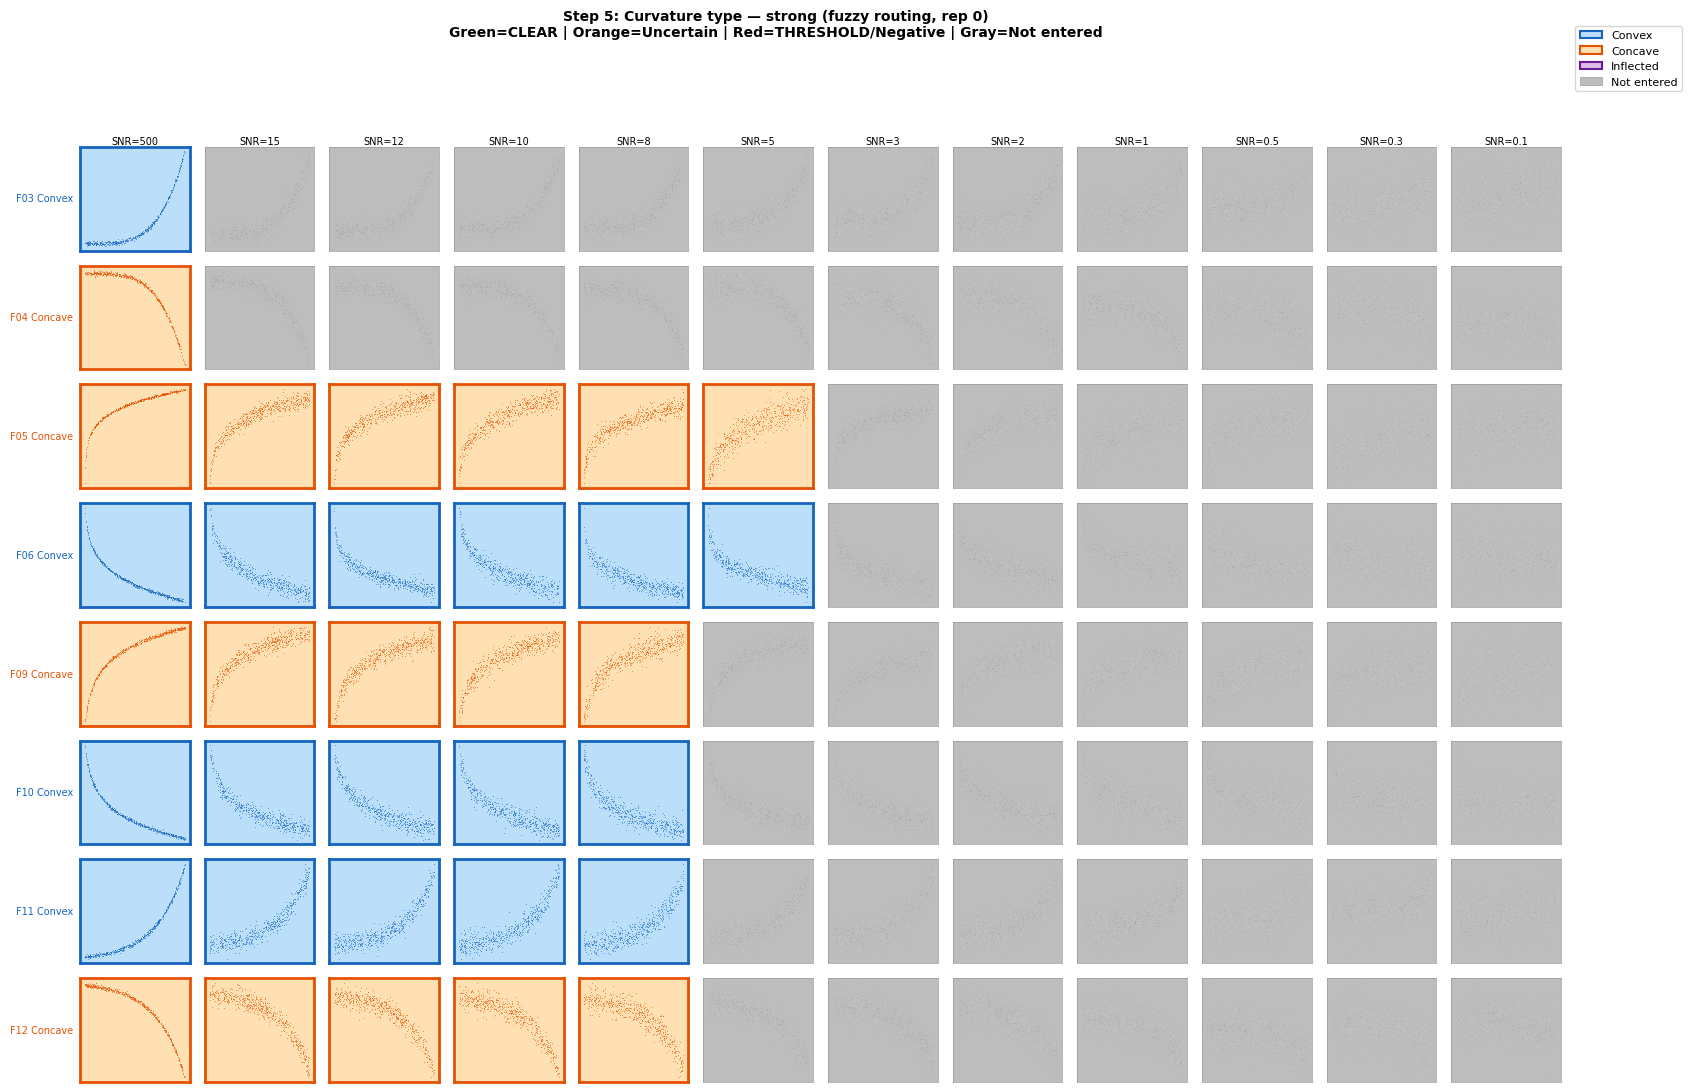

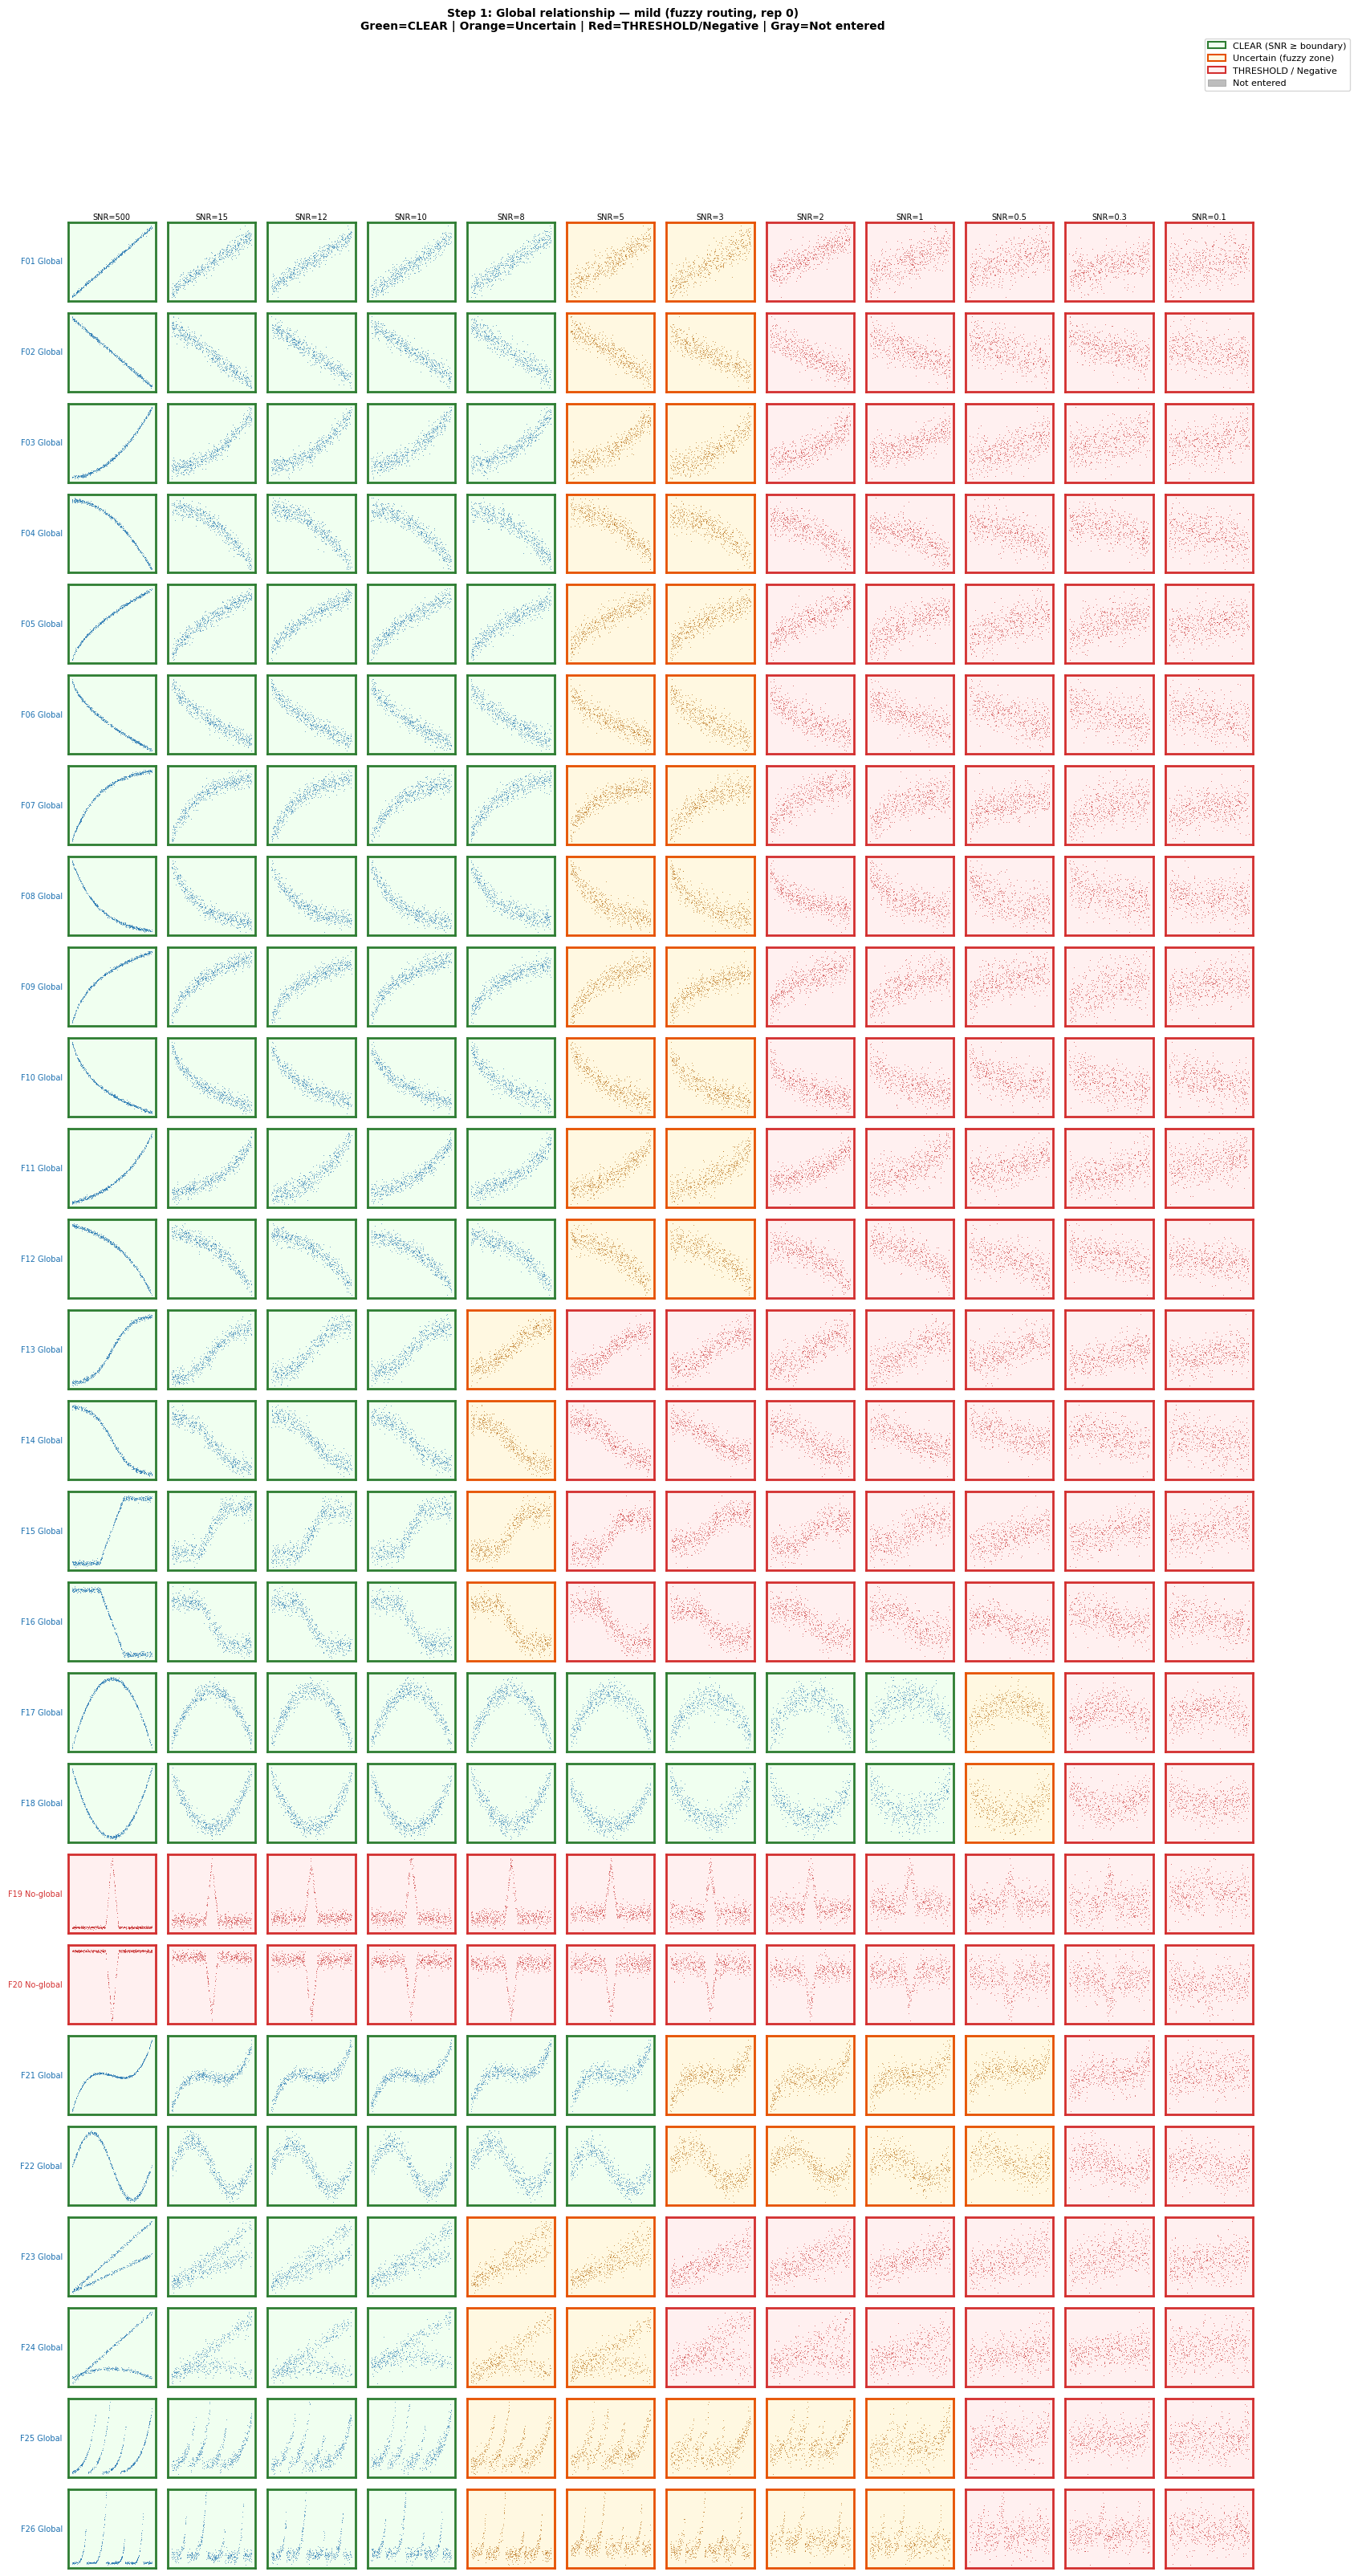

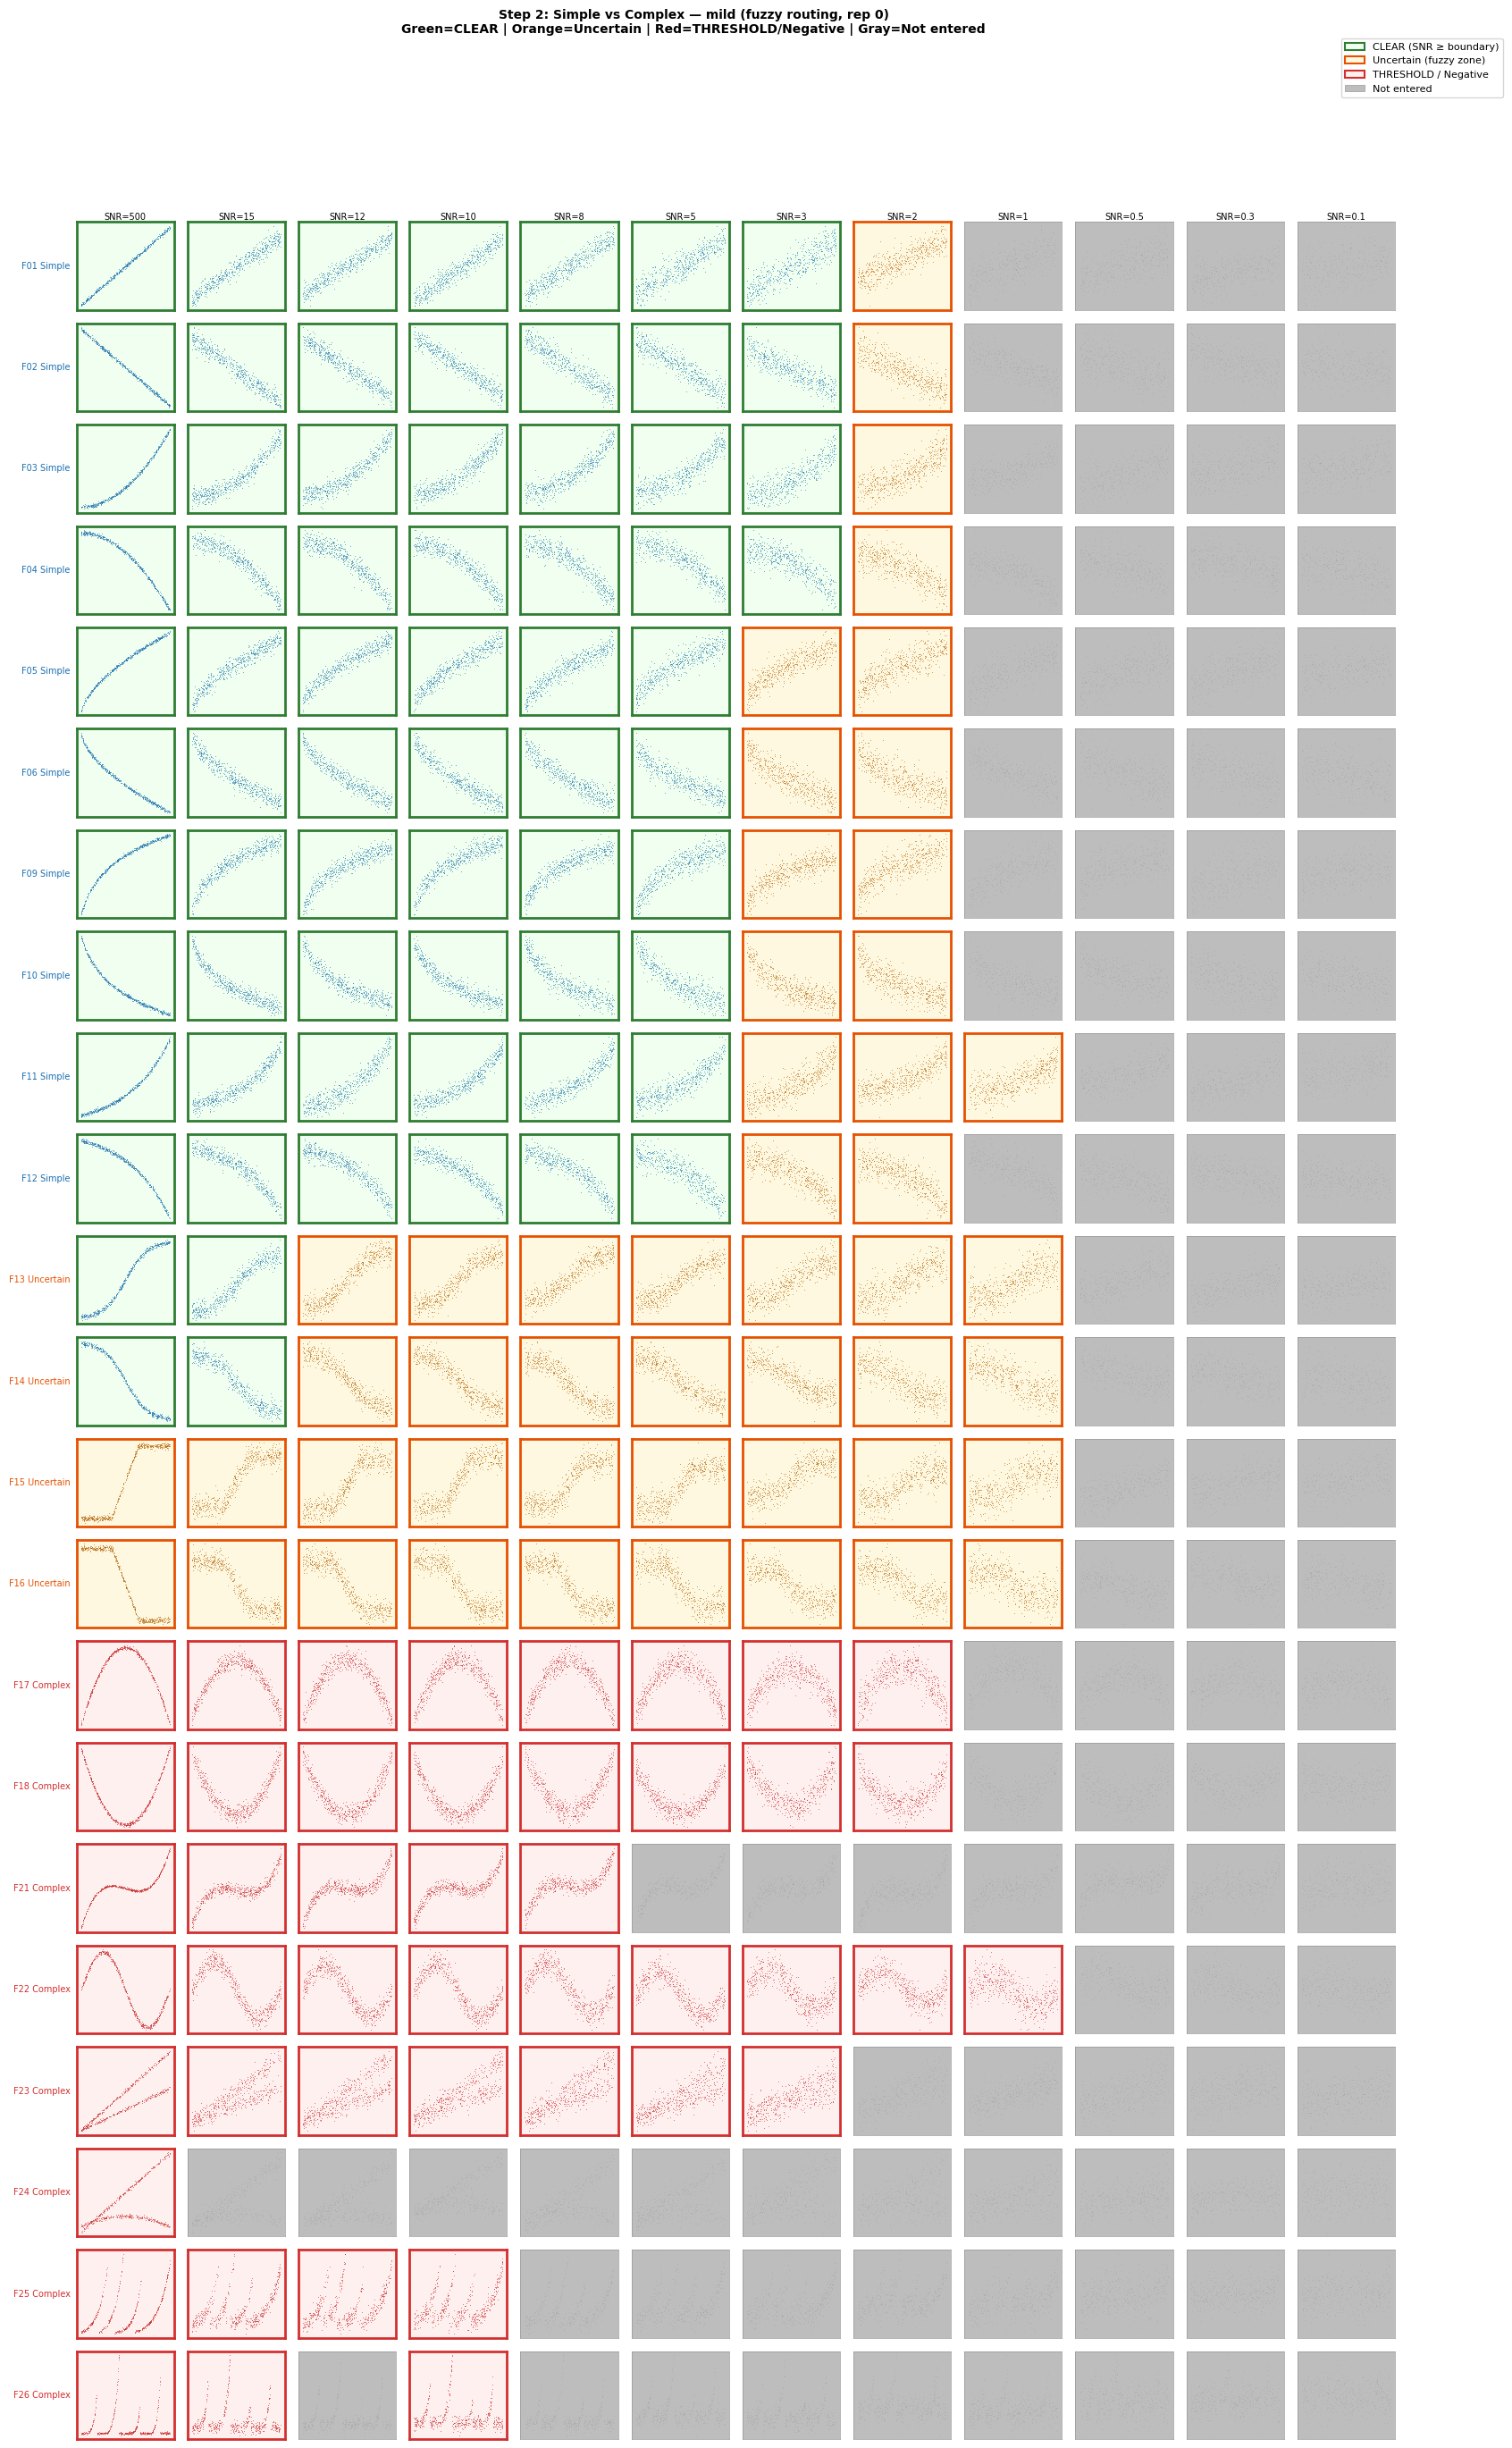

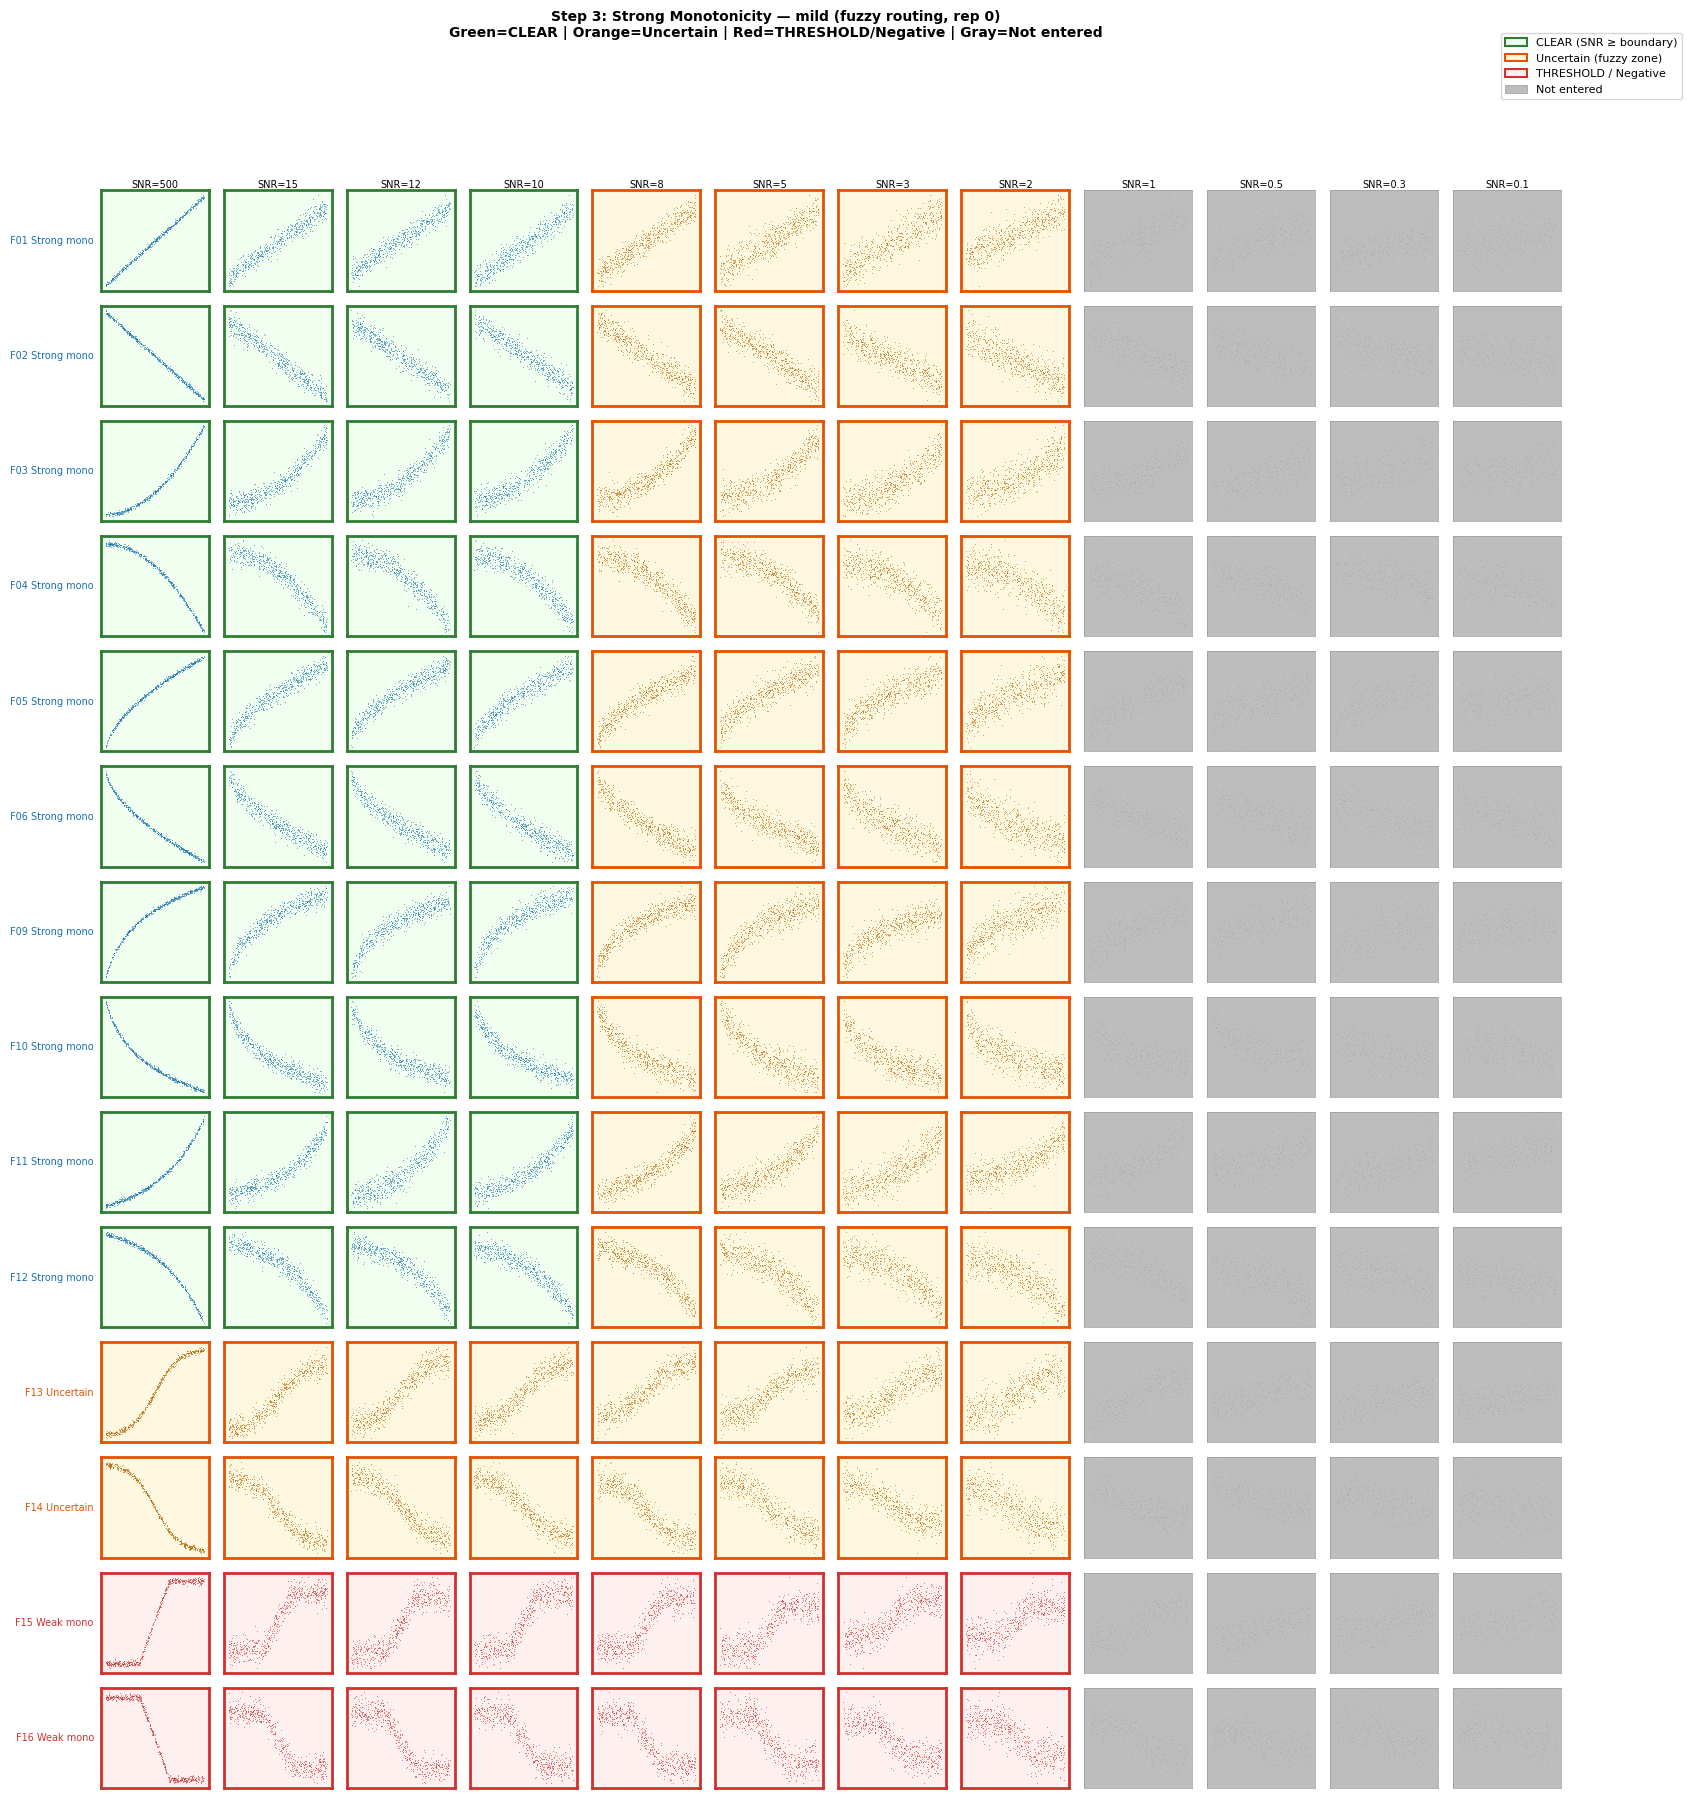

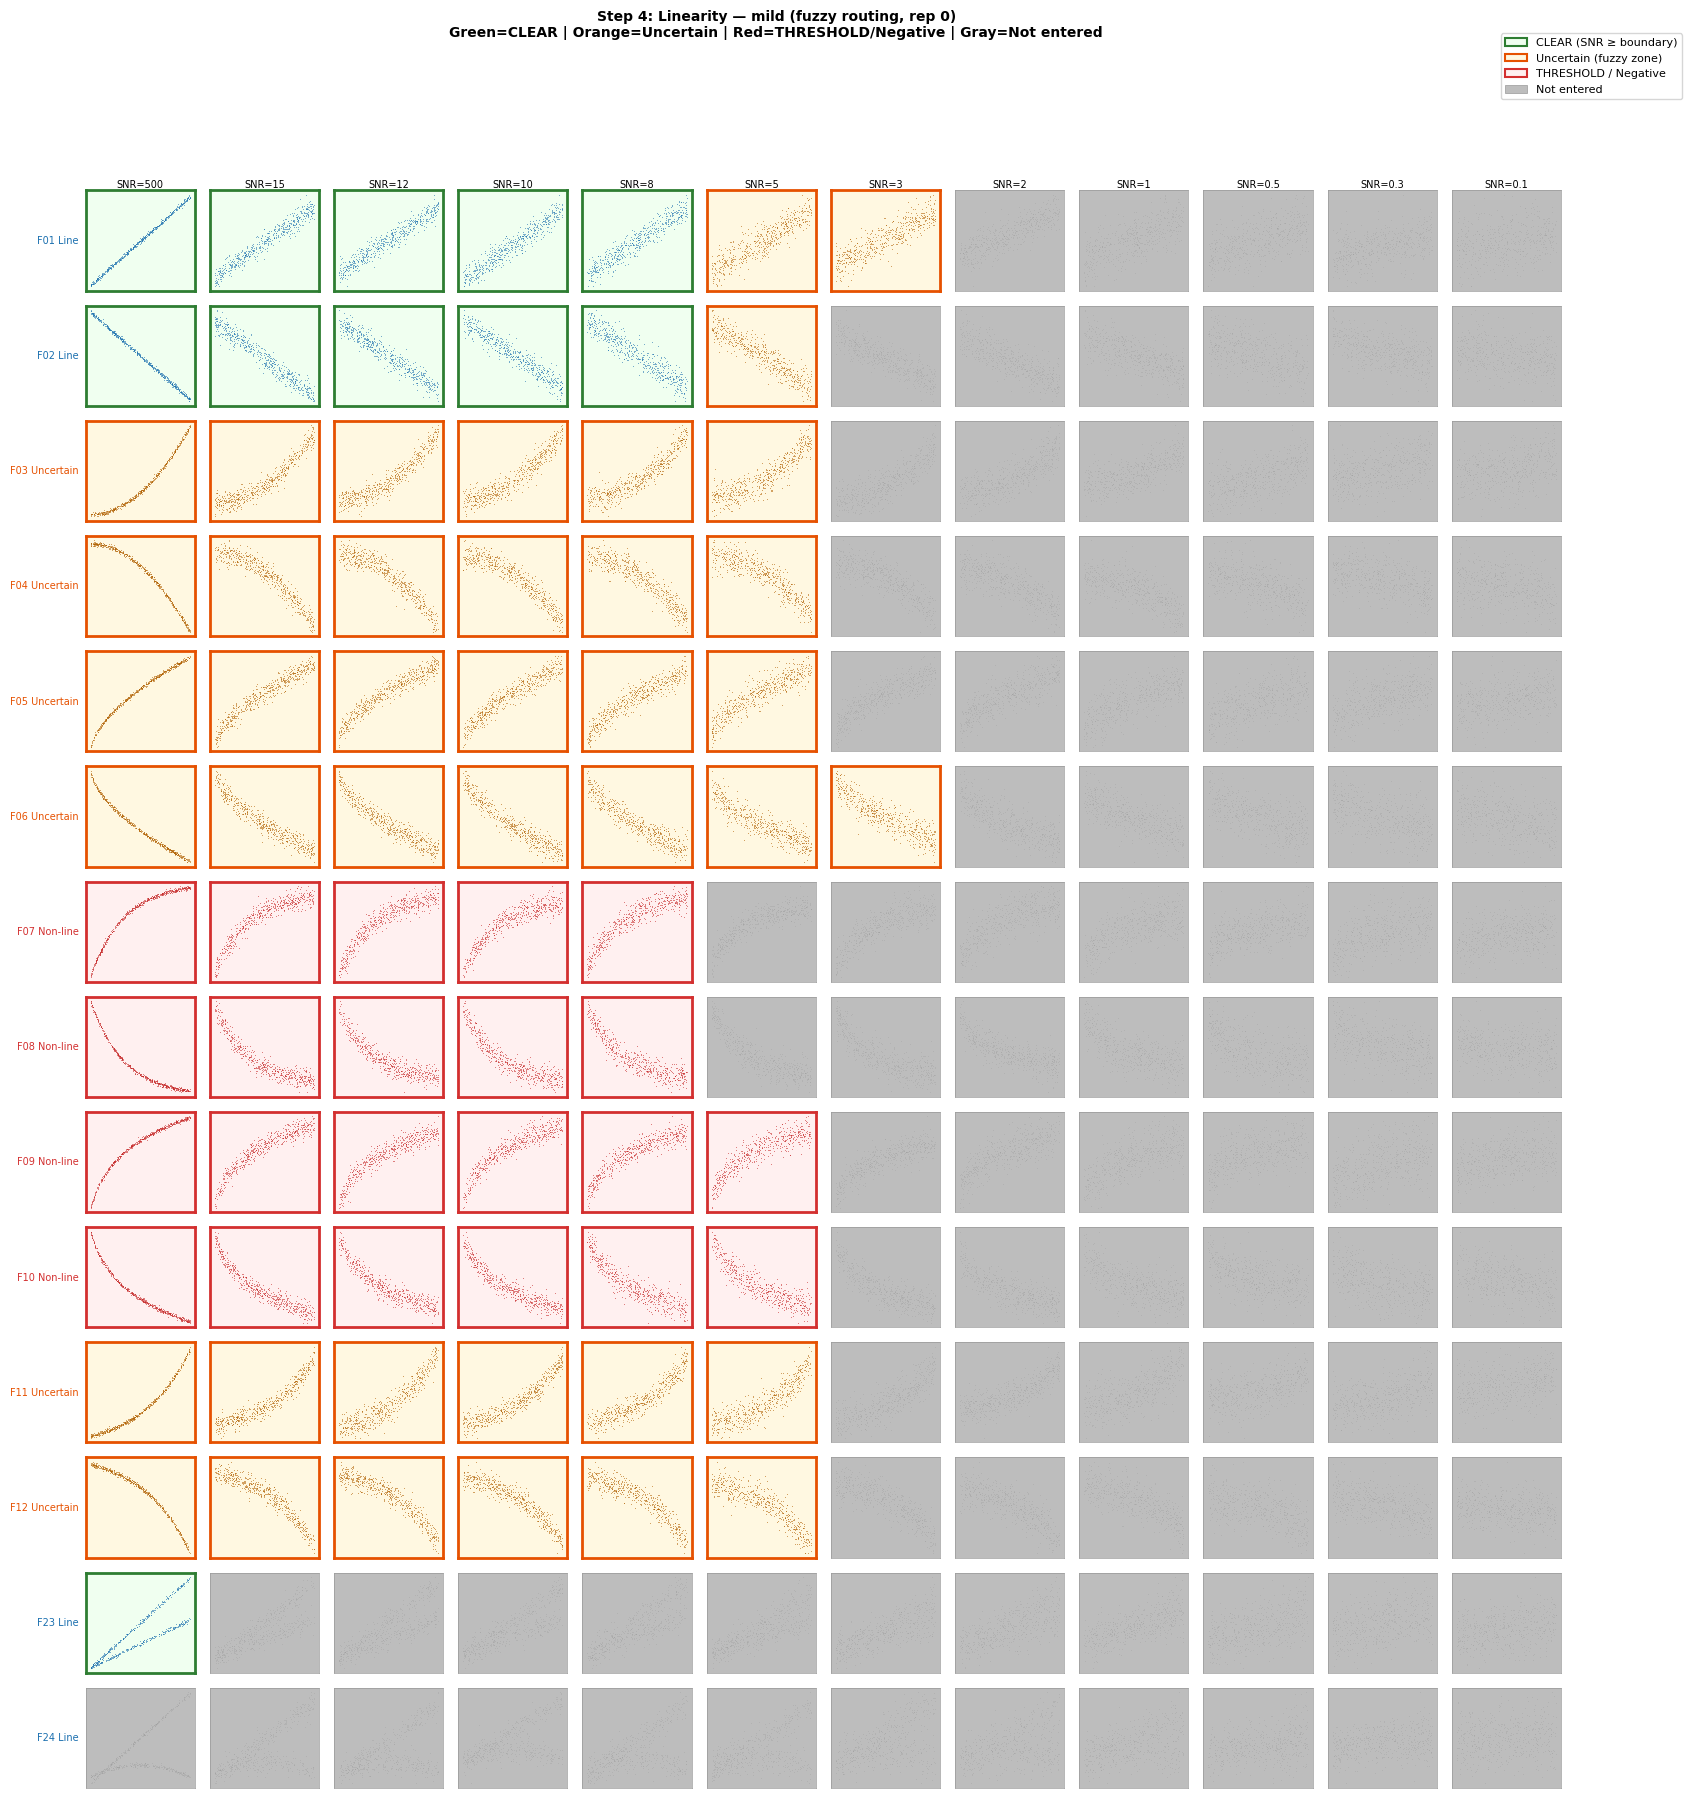

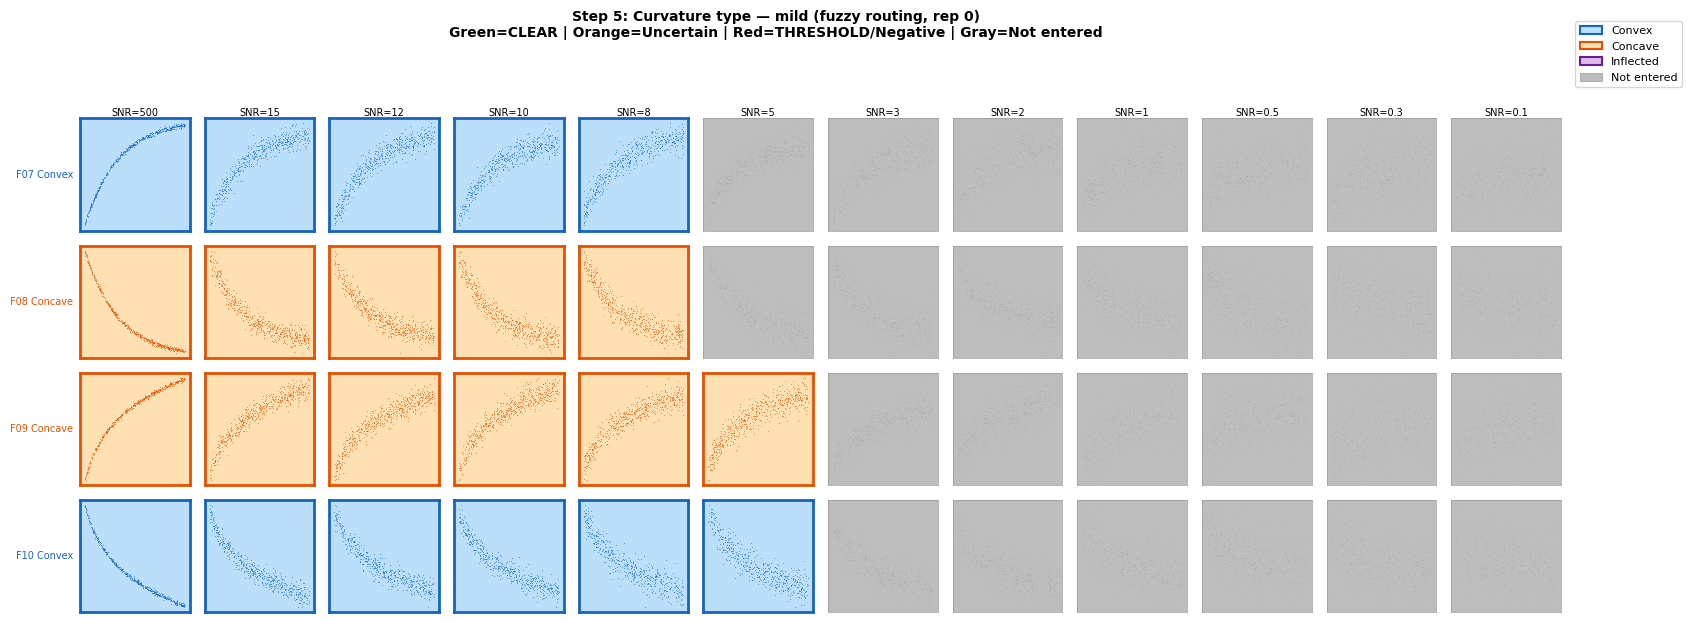

In [10]:
# ══════════════════════════════════════════════════════
#  Per-step scatter grid — both variants
#  Three-color scheme matching calibration notebooks:
#    Green  = CLEAR (SNR ≥ CLEAR_SNR)
#    Orange = Uncertain (THRESHOLD < SNR < CLEAR, or uncertain family)
#    Red    = THRESHOLD (SNR ≤ THRESHOLD_SNR) or negative family
#    Gray   = didn't pass fuzzy routing for prior steps
# ══════════════════════════════════════════════════════

CLR = {
    'green_bg': '#f0fff0', 'green_bd': '#2e7d32', 'green_pt': '#1a6faf',
    'orange_bg': '#fff8e1', 'orange_bd': '#E65100', 'orange_pt': '#b06000',
    'red_bg': '#fff0f0', 'red_bd': '#d32f2f', 'red_pt': '#c62828',
    'gray_bg': '#bdbdbd', 'gray_bd': '#999', 'gray_pt': '#999999',
}
S5_CLR = {
    'Convex':    ('#bbdefb', '#1565c0', '#1565c0'),
    'Concave':   ('#ffe0b2', '#e65100', '#e65100'),
    'Inflected': ('#e1bee7', '#6a1b9a', '#6a1b9a'),
}

def get_cell_style(group, snr, clear_snr, thresh_snr, entered, curv_class=None):
    if not entered:
        return CLR['gray_bg'], CLR['gray_pt'], CLR['gray_bd'], 0.2
    if group == 'negative':
        return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45
    if group == 'curvature' and curv_class:
        bg, pt, bd = S5_CLR.get(curv_class, (CLR['gray_bg'], CLR['gray_pt'], CLR['gray_bd']))
        return bg, pt, bd, 0.45
    if clear_snr is not None and snr >= clear_snr:
        return CLR['green_bg'], CLR['green_pt'], CLR['green_bd'], 0.45
    if thresh_snr is not None and snr <= thresh_snr:
        return CLR['red_bg'], CLR['red_pt'], CLR['red_bd'], 0.45
    return CLR['orange_bg'], CLR['orange_pt'], CLR['orange_bd'], 0.45

STEP_NAMES = {1: 'Global relationship', 2: 'Simple vs Complex',
              3: 'Strong Monotonicity', 4: 'Linearity', 5: 'Curvature type'}
STEP_LABELS = {
    1: {'positive': 'Global', 'negative': 'No-global'},
    2: {'positive': 'Simple', 'uncertain': 'Uncertain', 'negative': 'Complex'},
    3: {'positive': 'Strong mono', 'uncertain': 'Uncertain', 'negative': 'Weak mono'},
    4: {'positive': 'Line', 'uncertain': 'Uncertain', 'negative': 'Non-line'},
}
LABEL_COLORS = {
    'positive': '#1a6faf', 'uncertain': '#E65100',
    'negative': '#d32f2f', 'curvature': '#333',
}

TARGET_SNRS = [500, 15, 12, 10, 8, 5, 3, 2, 1, 0.5, 0.3, 0.1]

for vname in ['strong', 'mild']:
    v = variants[vname]
    ann = ANNOT[vname]
    curv_class = ann['CURVATURE_FAMILY_CLASS']

    all_snrs = sorted(v['snr_float'].unique(), reverse=True)
    snr_levels = []
    for t in TARGET_SNRS:
        closest = min(all_snrs, key=lambda s: abs(s - t))
        if closest not in snr_levels:
            snr_levels.append(closest)

    # ── Recompute fuzzy routing ──
    mic_vals = v['MIC'].values
    pred_s1 = pd.Series(fuzzy_mu(mic_vals, results['step1_mic']['L'],
                                  results['step1_mic']['U']) >= ALPHA, index=v.index)
    rho_vals, r_vals = v['abs_rho'].values, v['abs_r'].values
    mu_s2 = np.minimum(
        fuzzy_mu(rho_vals, results['step2_rho']['L'], results['step2_rho']['U']),
        fuzzy_mu(r_vals,   results['step2_r']['L'],   results['step2_r']['U']))
    pred_s2 = pred_s1 & (mu_s2 >= ALPHA)
    pred_s3 = pred_s2 & (fuzzy_mu(rho_vals, results['step3_rho']['L'],
                                   results['step3_rho']['U']) >= ALPHA)
    mu_s4_line = np.minimum(
        fuzzy_mu(r_vals, results['step4_r']['L'], results['step4_r']['U']),
        1.0 - fuzzy_mu(v['delta_bic'].values,
                        results['step4_bic']['L'], results['step4_bic']['U']))
    pred_s4_line = pred_s3 & (mu_s4_line >= ALPHA)
    pred_s4_nonline = pred_s3 & ~pred_s4_line

    # ── Build per-step configs ──
    all_fids = sorted(f for f in v['family_id'].unique() if f != 'Null')

    step_configs = []

    # Step 1
    s1_groups = {fid: ('negative' if fid in ann['NO_GLOBAL'] else 'positive')
                 for fid in all_fids}
    step_configs.append((1, all_fids, s1_groups,
                         ann['CLEAR_SNR_S1'], ann['THRESHOLD_SNR_S1'],
                         pd.Series(True, index=v.index), None))

    # Step 2
    s2_fams = sorted(set(ann['SIMPLE_FAM'] + ann.get('UNCERTAIN_S2', []) + ann['COMPLEX_FAM']))
    s2_groups = {}
    for fid in s2_fams:
        if fid in ann['COMPLEX_FAM']:
            s2_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_S2', []):
            s2_groups[fid] = 'uncertain'
        else:
            s2_groups[fid] = 'positive'
    step_configs.append((2, s2_fams, s2_groups,
                         ann['CLEAR_SNR_S2'], ann['THRESHOLD_SNR_S2'],
                         pred_s1, None))

    # Step 3
    s3_fams = sorted(set(ann['STRONG_MONO'] + ann.get('UNCERTAIN_MONO', []) + ann['WEAK_MONO']))
    s3_groups = {}
    for fid in s3_fams:
        if fid in ann['WEAK_MONO']:
            s3_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_MONO', []):
            s3_groups[fid] = 'uncertain'
        else:
            s3_groups[fid] = 'positive'
    step_configs.append((3, s3_fams, s3_groups,
                         ann['CLEAR_SNR_S3'], ann['THRESHOLD_SNR_S3'],
                         pred_s2, None))

    # Step 4
    s4_fams = sorted(set(ann['LINEAR_FAM'] + ann.get('UNCERTAIN_LINEAR', []) + ann['NONLINEAR_FAM']))
    s4_groups = {}
    for fid in s4_fams:
        if fid in ann['NONLINEAR_FAM']:
            s4_groups[fid] = 'negative'
        elif fid in ann.get('UNCERTAIN_LINEAR', []):
            s4_groups[fid] = 'uncertain'
        else:
            s4_groups[fid] = 'positive'
    step_configs.append((4, s4_fams, s4_groups,
                         ann['CLEAR_SNR_S4'], ann['THRESHOLD_SNR_S4'],
                         pred_s3, None))

    # Step 5
    s5_fams = sorted(curv_class.keys())
    s5_groups = {fid: 'curvature' for fid in s5_fams}
    step_configs.append((5, s5_fams, s5_groups, {}, {},
                         pred_s4_nonline, curv_class))

    # ── Draw grids ──
    for step, families, groups, clear_dict, thresh_dict, enter_mask, curv_cls in step_configs:
        n_fam = len(families)
        n_snr = len(snr_levels)
        if n_fam == 0:
            continue

        cw, ch = 1.3, 1.2
        fig, axes = plt.subplots(n_fam, n_snr,
                                  figsize=(n_snr * cw + 3, n_fam * ch + 1.5),
                                  squeeze=False)

        for i, fid in enumerate(families):
            group = groups[fid]
            cc = curv_cls.get(fid) if curv_cls else None
            c_snr = clear_dict.get(fid)
            t_snr = thresh_dict.get(fid)

            for j, snr in enumerate(snr_levels):
                ax = axes[i][j]
                mask = (v['family_id'] == fid) & np.isclose(v['snr_float'], snr)
                rows_here = v.loc[mask]

                if len(rows_here) == 0:
                    ax.set_facecolor(CLR['gray_bg'])
                    ax.set_xticks([]); ax.set_yticks([])
                    for sp in ax.spines.values():
                        sp.set_color(CLR['gray_bd']); sp.set_linewidth(0.5)
                    if i == 0:
                        snr_lbl = f'{snr:.0f}' if snr >= 1 else f'{snr:.1f}'
                        ax.set_title(f'SNR={snr_lbl}', fontsize=7, pad=2)
                    if j == 0:
                        if step == 5:
                            lbl = f'{fid} {cc}'
                        else:
                            lbl = f'{fid} {STEP_LABELS[step].get(group, "")}'
                        ax.set_ylabel(lbl, fontsize=7, rotation=0,
                                      ha='right', va='center', labelpad=5,
                                      color=CLR['gray_bd'])
                    continue

                entered_rows = rows_here[enter_mask.reindex(rows_here.index, fill_value=False)]
                entered = len(entered_rows) > 0
                rep = entered_rows.iloc[0] if entered else rows_here.iloc[0]
                cid = rep['case_id']

                bg, pt_c, bdr, pt_a = get_cell_style(
                    group, snr, c_snr, t_snr, entered, cc)

                ax.set_facecolor(bg)
                for sp in ax.spines.values():
                    sp.set_color(bdr)
                    sp.set_linewidth(2.0 if entered else 0.5)

                if cid in case_idx_map:
                    idx = case_idx_map[cid]
                    xp, yp = x_all[idx], y_all[idx]
                    ax.scatter(xp, yp, s=0.5, c=pt_c, alpha=pt_a, linewidths=0)

                ax.set_xticks([]); ax.set_yticks([])

                if i == 0:
                    snr_lbl = f'{snr:.0f}' if snr >= 1 else f'{snr:.1f}'
                    ax.set_title(f'SNR={snr_lbl}', fontsize=7, pad=2)
                if j == 0:
                    if step == 5:
                        lbl = f'{fid} {cc}'
                        lbl_c = S5_CLR.get(cc, (None, None, '#333'))[2]
                    else:
                        lbl = f'{fid} {STEP_LABELS[step].get(group, "")}'
                        lbl_c = LABEL_COLORS.get(group, '#333')
                    ax.set_ylabel(lbl, fontsize=7, rotation=0,
                                  ha='right', va='center', labelpad=5,
                                  color=lbl_c)

        # Legend
        if step == 5:
            handles = []
            for cls, (bg, pt, bd) in S5_CLR.items():
                handles.append(plt.Rectangle((0,0),1,1, fc=bg, ec=bd, lw=1.5, label=cls))
            handles.append(plt.Rectangle((0,0),1,1, fc=CLR['gray_bg'], ec=CLR['gray_bd'],
                           lw=0.5, label='Not entered'))
        else:
            handles = [
                plt.Rectangle((0,0),1,1, fc=CLR['green_bg'], ec=CLR['green_bd'],
                               lw=1.5, label='CLEAR (SNR ≥ boundary)'),
                plt.Rectangle((0,0),1,1, fc=CLR['orange_bg'], ec=CLR['orange_bd'],
                               lw=1.5, label='Uncertain (fuzzy zone)'),
                plt.Rectangle((0,0),1,1, fc=CLR['red_bg'], ec=CLR['red_bd'],
                               lw=1.5, label='THRESHOLD / Negative'),
                plt.Rectangle((0,0),1,1, fc=CLR['gray_bg'], ec=CLR['gray_bd'],
                               lw=0.5, label='Not entered'),
            ]

        fig.suptitle(f'Step {step}: {STEP_NAMES[step]} — {vname} (fuzzy routing, rep 0)\n'
                     f'Green=CLEAR | Orange=Uncertain | Red=THRESHOLD/Negative | Gray=Not entered',
                     fontsize=10, fontweight='bold')
        fig.legend(handles=handles, loc='upper right', fontsize=8,
                   bbox_to_anchor=(0.99, 0.97))
        plt.tight_layout(rect=[0.08, 0, 0.93, 0.92])
        plt.show()
        print()

In [11]:
# ══════════════════════════════════════════════════════
#  Save combined fuzzy parameters
# ══════════════════════════════════════════════════════

combined_params = {
    'alpha': ALPHA,
    'training': 'combined (strong + mild)',
    'step1_mic': results['step1_mic'],
    'step2_rho': results['step2_rho'],
    'step2_r':   results['step2_r'],
    'step3_rho': results['step3_rho'],
    'step4_r':   results['step4_r'],
    'step4_delta_bic': {
        **results['step4_bic'],
        'decreasing': True,
        'definition': 'BIC_linear - min(BIC_quadratic, BIC_cubic)',
    },
    'step5_curvature': {
        'curvature_strength': {
            **results['step5_curved'],
            'increasing': True,
        },
        'dominance_threshold': DOMINANCE_THRESH,
        'routing': (
            'mu(curvature_strength) >= alpha → curved; '
            'then f2_dominance >= 0.75 → sign(f2) → Convex/Concave; '
            'f2_dominance < 0.75 → Inflected'
        ),
    },
}

out_path = OUT_DIR / 'fuzzy_params_combined.json'
with open(out_path, 'w') as f:
    json_mod.dump(combined_params, f, indent=2)
print(f'Saved to {out_path}')
print(json_mod.dumps(combined_params, indent=2))

Saved to output/S3_polyfit/fuzzy_params_combined.json
{
  "alpha": 0.5,
  "training": "combined (strong + mild)",
  "step1_mic": {
    "L": 0.18000000000000002,
    "U": 0.9200000000000009,
    "mse": 0.048672003966497915
  },
  "step2_rho": {
    "L": 0.5700000000000003,
    "U": 0.9800000000000018,
    "mse": 0.0401846787558112
  },
  "step2_r": {
    "L": 0.5500000000000003,
    "U": 0.9800000000000011,
    "mse": 0.052661011708263955
  },
  "step3_rho": {
    "L": 0.7700000000000002,
    "U": 1.0000000000000004,
    "mse": 0.09913083116812971
  },
  "step4_r": {
    "L": 0.9100000000000004,
    "U": 1.0000000000000004,
    "mse": 0.09870994511277835
  },
  "step4_delta_bic": {
    "L": -6.5,
    "U": 38.0,
    "mse": 0.06774212774005063,
    "decreasing": true,
    "definition": "BIC_linear - min(BIC_quadratic, BIC_cubic)"
  },
  "step5_curvature": {
    "curvature_strength": {
      "L": 0.5153023485749285,
      "U": 0.5253023485749285,
      "mse": 0.0,
      "increasing": true
